In [1]:
import sys
from pathlib import Path
# Make the repo root importable regardless of CWD or machine: walk up from the
# working dir until we hit a repo marker, then put that dir on sys.path.
_start = Path.cwd()
_root = next((p for p in (_start, *_start.parents)
              if (p / ".git").exists() or (p / "setup.py").exists()), _start)
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

In [ ]:
from metab_processing.metab_travlr_config import PROJECT_DATA_DIR, DATA_DIR as METAB_DATA_DIR

XENIUM2_DATA_DIR = f'{METAB_DATA_DIR}/Xenium2_HVG_Rep'
DATASET_NAME = 'Primary_Dermal_Melanoma'
# DATASET_NAME = 'Human_Lung'
DATA_DIR = f'{XENIUM2_DATA_DIR}/{DATASET_NAME}'

In [2]:
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt

In [3]:
adata = sc.read_h5ad(f'{DATA_DIR}/adata.h5ad')
adata

AnnData object with n_obs × n_vars = 112551 × 5006
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', '_scvi_batch', '_scvi_labels', 'leiden_scVI_res_0.5', 'leiden_scVI_res_2.5', 'leiden_scVI_res_2', 'leiden_scVI_res_1.5', 'leiden_scVI_res_1', 'leiden_scVI_res_0.75', 'leiden_scVI_res_0.65', 'leiden_scVI_res_0.375', 'leiden_scVI_res_0.25', 'leiden_scVI_res_0.1', 'leiden_scVI_res_0.05', 'cd8', 'cd4', 't_cell', 'Tier1', 'Tier2', 'Tier3'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'Tier1_colors', 'Tier2_colors', 'Tier3_colors', '_scvi_manager_uuid', '_scvi_uuid', 'leiden_scVI_res_0.05', 'leiden_scVI_res_0.05_colors', 'leiden_scVI_res_0.1', 'leiden_scVI_res_0.1_colors', 'leiden_scVI_res_0.25', 'leiden_scVI_res_0.25_colors', 'leiden_scVI_res_0.375', 'leid

/tmp/ipykernel_2773824/12019399.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, spot_size=5, show=False, title=DATASET_NAME, color='leiden_scVI_res_0.5');


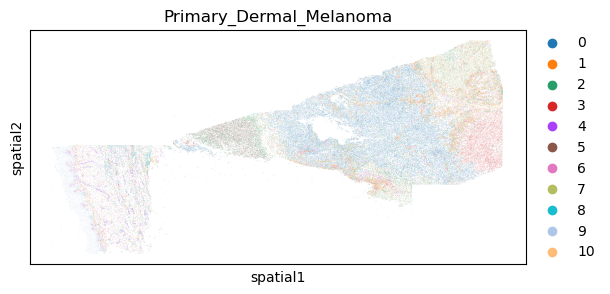

In [4]:
sc.pl.spatial(adata, spot_size=5, show=False, title=DATASET_NAME, color='leiden_scVI_res_0.5');

In [5]:
# Make sure counts layer exists
if 'counts' not in adata.layers:
    adata.layers['counts'] = adata.X.copy()

# Build log_norm layer from counts if it doesn't exist
if 'log_norm' not in adata.layers:
    adata.X = adata.layers['counts'].copy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    adata.layers['log_norm'] = adata.X.copy()
    # Restore raw counts to X
    adata.X = adata.layers['counts'].copy()

print("Layers available:", list(adata.layers.keys()))
print("X max (should be large if raw counts):", adata.X.max())
print("log_norm max (should be small, ~log scale):", adata.layers['log_norm'].max())

/tmp/ipykernel_2773824/1663927226.py:8: UserWarning: Some cells have zero counts
  sc.pp.normalize_total(adata, target_sum=1e4)


Layers available: ['counts', 'log_norm']
X max (should be large if raw counts): 290.0
log_norm max (should be small, ~log scale): 9.210441


In [6]:
# resolutions = [2.5, 2, 1.5, 1, 0.75, 0.65, 0.5, 0.375, 0.25, 0.1, 0.05]
resolutions = [2.5, 2, 1.5, 1, 0.75, 0.65, 0.5]
def res_label(res):
    return f'leiden_scVI_res_{res}'
res_labels = [res_label(res) for res in resolutions]

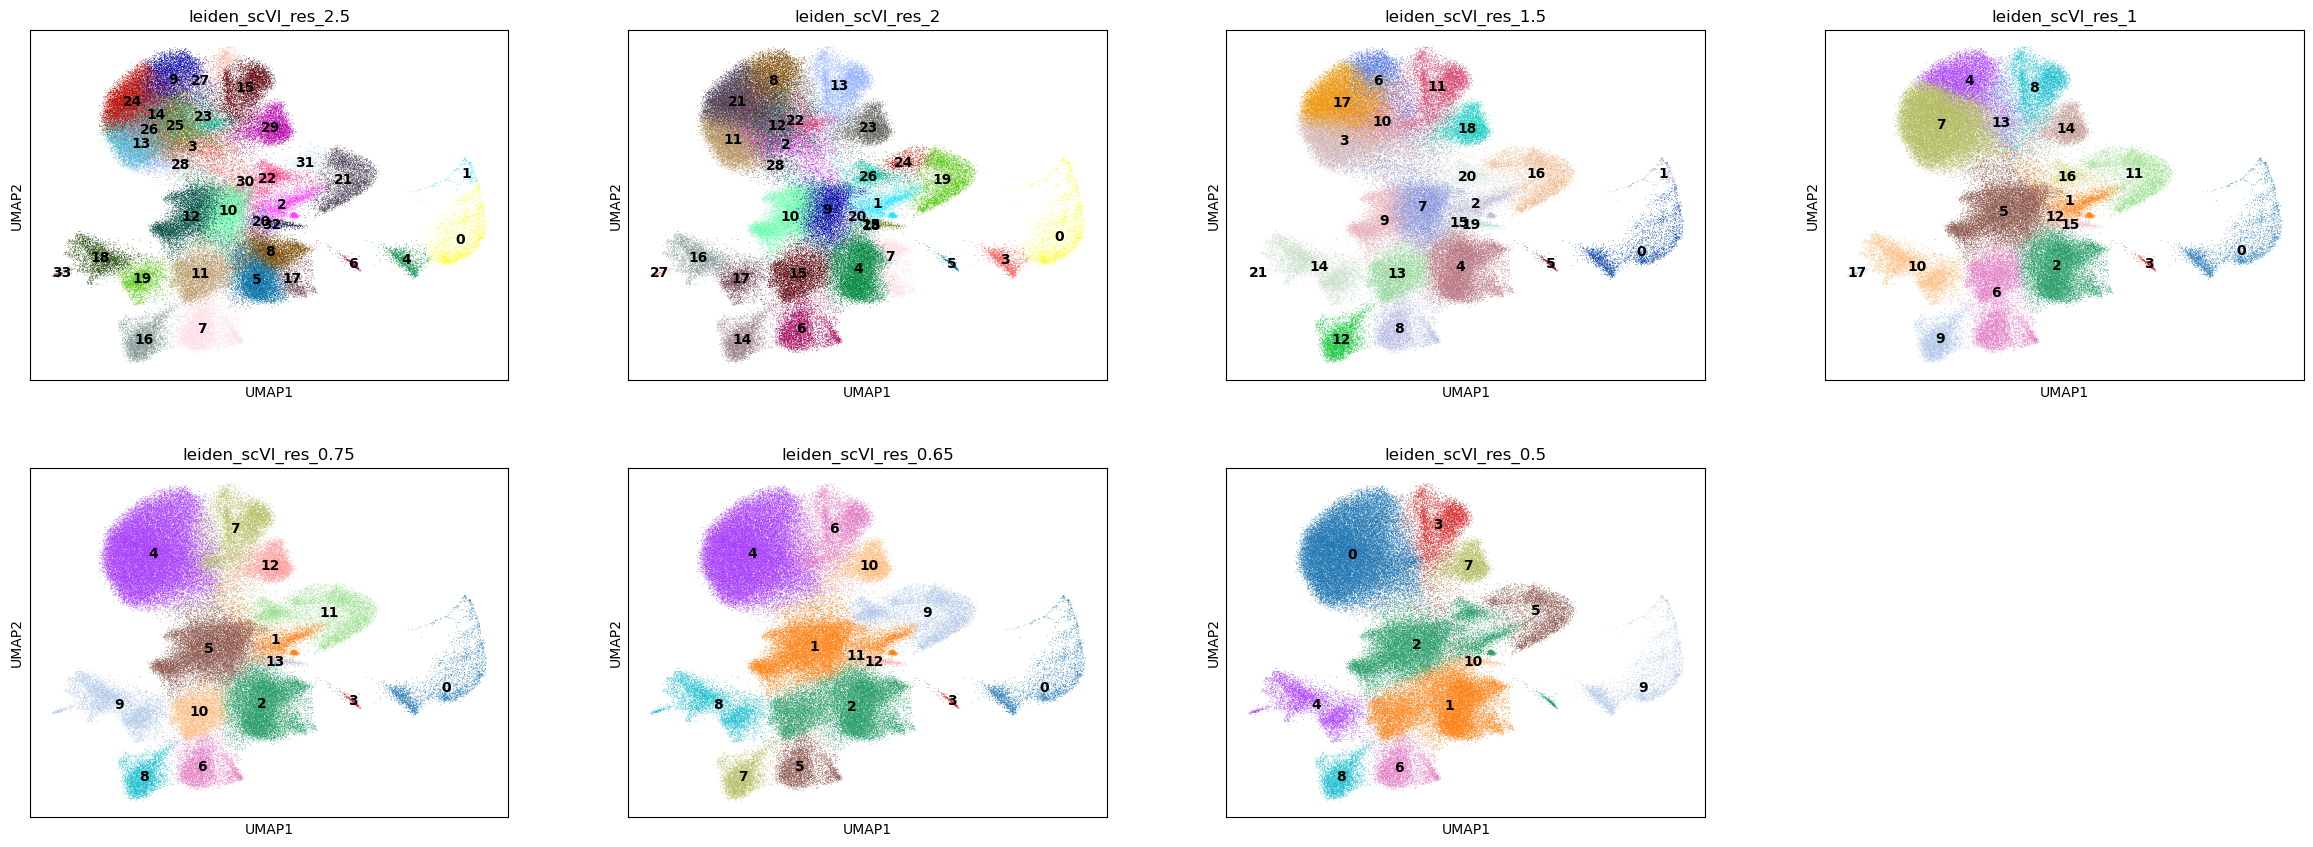

In [7]:
sc.pl.umap(adata, color=res_labels, legend_loc="on data")


RESOLUTION: leiden_scVI_res_2.5


/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/t


--- Top DE genes per cluster (log_norm) ---
Cluster 0: ['DSG1', 'LAD1', 'DMKN', 'JUP', 'TMEM45A', 'GJA1', 'CDKN1A', 'NDRG1', 'GJB6', 'GSDMC', 'DHCR24', 'MALL', 'CDKN2B', 'CXADR', 'ST14']
Cluster 1: ['KPRP', 'CDSN', 'DMKN', 'ARG1', 'HPGD', 'IL18', 'IDE', 'CPA4', 'SERPINA12', 'TMEM45A', 'GDA', 'HOPX', 'CREG1', 'PIM1', 'HMOX1']
Cluster 2: ['PSG1', 'LGALS13', 'EIF5AL1', 'DEFA1', 'FMN2', 'IL5', 'HDC', 'GPR149', 'PGA3', 'ADRA1D', 'POTEF', 'NODAL', 'OPN1LW', 'CACNG4', 'TDGF1']
Cluster 3: ['EEF1G', 'FBL', 'S100A1', 'CD44', 'MLANA', 'PRAME', 'RASSF3', 'HNRNPA1L2', 'H3F3B', 'ANXA5', 'HSPA8', 'CDK2', 'TDRD3', 'LDHA', 'HSPD1']
Cluster 4: ['DST', 'COL17A1', 'DSG3', 'CA12', 'CXADR', 'ITGB4', 'SLC2A1', 'TP63', 'ITGA6', 'ST14', 'COL7A1', 'APP', 'FGFR3', 'SEMA4B', 'LAMB3']
Cluster 5: ['CD8A', 'CD3E', 'GZMA', 'CD2', 'KLRK1', 'CD96', 'IL2RG', 'CCND2', 'ITGAL', 'IKZF3', 'GZMK', 'GIMAP4', 'GZMH', 'IKZF1', 'SH2D1A']
Cluster 6: ['CTSG', 'KIT', 'HPGD', 'MS4A2', 'GATA2', 'CMA1', 'SLC18A2', 'HDC', 'SIGLEC6', '

/tmp/ipykernel_2773824/3294693258.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores = adata.obs.groupby(groupby_key)[score_cols].mean()
/tmp/ipykernel_2773824/3294693258.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores['cell_count'] = adata.obs.groupby(groupby_key).size()



--- Marker set scores and cell counts per cluster (log_norm) ---
                     Cytotoxic_CD8_score  Exhausted_CD8_score  Treg_score  \
leiden_scVI_res_2.5                                                         
0                              -0.341417            -0.373760   -0.237443   
1                              -0.137350            -0.130235   -0.105874   
2                              -0.003940            -0.002298    0.009647   
3                              -0.098536            -0.106981   -0.054892   
4                              -0.120200            -0.161260   -0.123733   
5                               0.938757             0.631009    0.324126   
6                              -0.079770            -0.059569    0.010179   
7                              -0.092124            -0.085821   -0.015260   
8                               0.286582             0.315230    0.632310   
9                              -0.254953            -0.274238   -0.206388   
10        

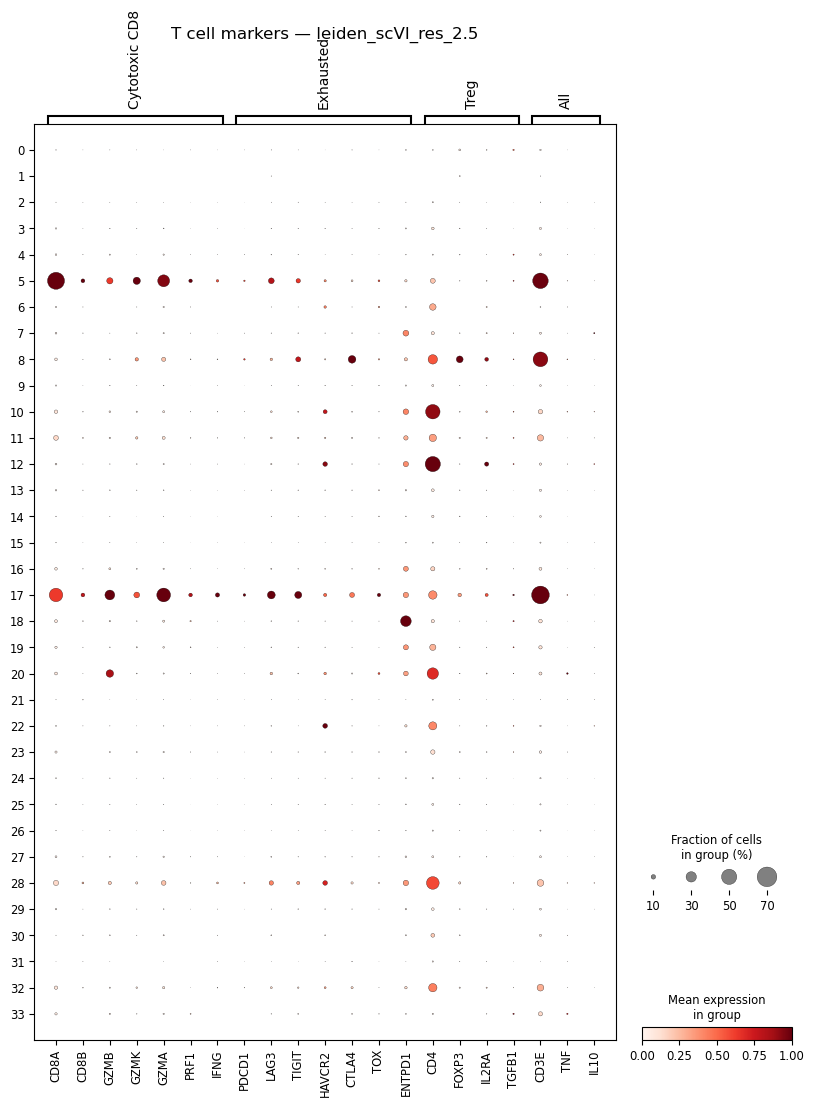


RESOLUTION: leiden_scVI_res_2


/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/t


--- Top DE genes per cluster (log_norm) ---
Cluster 0: ['DSG1', 'DMKN', 'TMEM45A', 'LAD1', 'JUP', 'GJA1', 'CDKN1A', 'GJB6', 'NDRG1', 'DHCR24', 'MALL', 'A2ML1', 'GSDMC', 'PIM1', 'CXADR']
Cluster 1: ['PSG1', 'LGALS13', 'DEFA1', 'HDC', 'IL5', 'ADRA1D', 'EIF5AL1', 'GPR149', 'TDGF1', 'PGA3', 'NODAL', 'OPN1LW', 'CACNG4', 'CASC8', 'FMN2']
Cluster 2: ['EEF1G', 'FBL', 'S100A1', 'MLANA', 'CD44', 'PRAME', 'ANXA5', 'RASSF3', 'H3F3B', 'CDK2', 'LDHA', 'HNRNPA1L2', 'TDRD3', 'HSPA8', 'HSPD1']
Cluster 3: ['DST', 'COL17A1', 'DSG3', 'CA12', 'ITGB4', 'CXADR', 'SLC2A1', 'TP63', 'ITGA6', 'ST14', 'COL7A1', 'APP', 'FGFR3', 'SEMA4B', 'LAMB3']
Cluster 4: ['CD3E', 'CD8A', 'GZMA', 'CD2', 'IL2RG', 'GIMAP4', 'CD96', 'CCND2', 'IKZF1', 'ITGAL', 'KLRK1', 'IKZF3', 'GZMK', 'GPR174', 'SH2D1A']
Cluster 5: ['CTSG', 'KIT', 'HPGD', 'MS4A2', 'GATA2', 'CMA1', 'SLC18A2', 'HDC', 'SIGLEC6', 'BTK', 'IL1RL1', 'ADCYAP1', 'HPGDS', 'BMP2K', 'CSF2RB']
Cluster 6: ['COL5A1', 'THY1', 'COL5A2', 'POSTN', 'CTSK', 'CCDC80', 'COMP', 'THBS1', 

/tmp/ipykernel_2773824/3294693258.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores = adata.obs.groupby(groupby_key)[score_cols].mean()
/tmp/ipykernel_2773824/3294693258.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores['cell_count'] = adata.obs.groupby(groupby_key).size()



--- Marker set scores and cell counts per cluster (log_norm) ---
                   Cytotoxic_CD8_score  Exhausted_CD8_score  Treg_score  \
leiden_scVI_res_2                                                         
0                            -0.320193            -0.348444   -0.223402   
1                            -0.005118            -0.003352    0.010323   
2                            -0.107666            -0.115124   -0.065611   
3                            -0.120281            -0.161618   -0.125178   
4                             0.724540             0.496019    0.354876   
5                            -0.079967            -0.059702    0.010951   
6                            -0.092141            -0.086049   -0.015436   
7                             0.480456             0.529548    0.828097   
8                            -0.251408            -0.271380   -0.204034   
9                             0.008654             0.034456    0.261161   
10                           -0.06

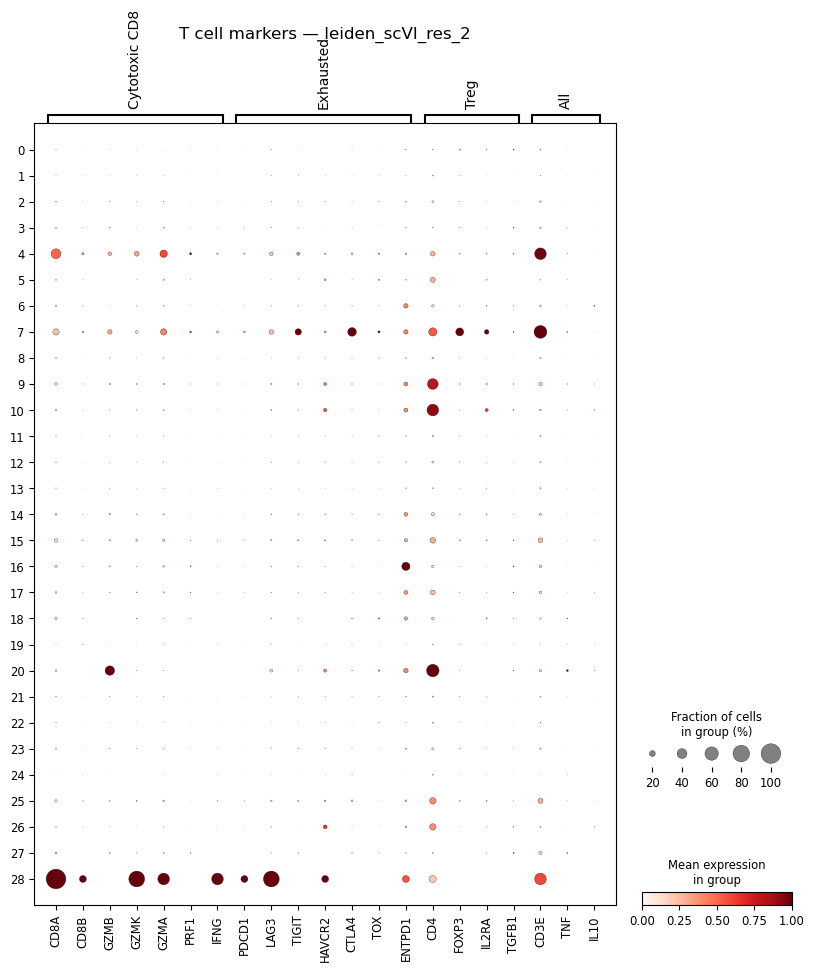


RESOLUTION: leiden_scVI_res_1.5


/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/t


--- Top DE genes per cluster (log_norm) ---
Cluster 0: ['LAD1', 'DSG1', 'CXADR', 'NDRG1', 'ST14', 'GJA1', 'GSDMC', 'JUP', 'SLC2A1', 'DSG3', 'CA12', 'SEMA4B', 'CDKN1A', 'GJB6', 'NECTIN1']
Cluster 1: ['KPRP', 'CDSN', 'DMKN', 'ARG1', 'HPGD', 'IL18', 'IDE', 'CPA4', 'SERPINA12', 'TMEM45A', 'GDA', 'HOPX', 'CREG1', 'PIM1', 'HMOX1']
Cluster 2: ['PSG1', 'HDC', 'LGALS13', 'IL5', 'ADRA1D', 'DEFA1', 'EIF5AL1', 'IL17RB', 'TDGF1', 'PCA3', 'NODAL', 'OPN1LW', 'CACNG4', 'CASC8', 'FMN2']
Cluster 3: ['FBL', 'S100A1', 'EEF1G', 'PRAME', 'MLANA', 'CD44', 'ATP1A1', 'ERBB3', 'ADGRG1', 'EDNRB', 'CDK2', 'AKT2', 'TFAP2A', 'CD59', 'RASSF3']
Cluster 4: ['CD3E', 'CD8A', 'CD2', 'GZMA', 'IL2RG', 'CCND2', 'CD96', 'IKZF1', 'GIMAP4', 'ITGAL', 'SH2D1A', 'IKZF3', 'KLRK1', 'LCK', 'GPR174']
Cluster 5: ['CTSG', 'KIT', 'HPGD', 'MS4A2', 'GATA2', 'CMA1', 'SLC18A2', 'HDC', 'SIGLEC6', 'BTK', 'IL1RL1', 'ADCYAP1', 'HPGDS', 'BMP2K', 'CSF2RB']
Cluster 6: ['BIRC5', 'STMN1', 'TUBB', 'TYMS', 'H3F3B', 'AKT2', 'PRNP', 'KPNA2', 'RAN', 'AC

/tmp/ipykernel_2773824/3294693258.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores = adata.obs.groupby(groupby_key)[score_cols].mean()
/tmp/ipykernel_2773824/3294693258.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores['cell_count'] = adata.obs.groupby(groupby_key).size()



--- Marker set scores and cell counts per cluster (log_norm) ---
                     Cytotoxic_CD8_score  Exhausted_CD8_score  Treg_score  \
leiden_scVI_res_1.5                                                         
0                              -0.257104            -0.292248   -0.194288   
1                              -0.137350            -0.130235   -0.105874   
2                              -0.007719            -0.006437    0.007757   
3                              -0.188451            -0.199906   -0.143733   
4                               0.668970             0.498813    0.448861   
5                              -0.079633            -0.059268    0.011239   
6                              -0.235180            -0.255545   -0.189810   
7                              -0.014204             0.018172    0.246387   
8                              -0.094438            -0.088419   -0.020704   
9                              -0.067231            -0.020456    0.293134   
10        

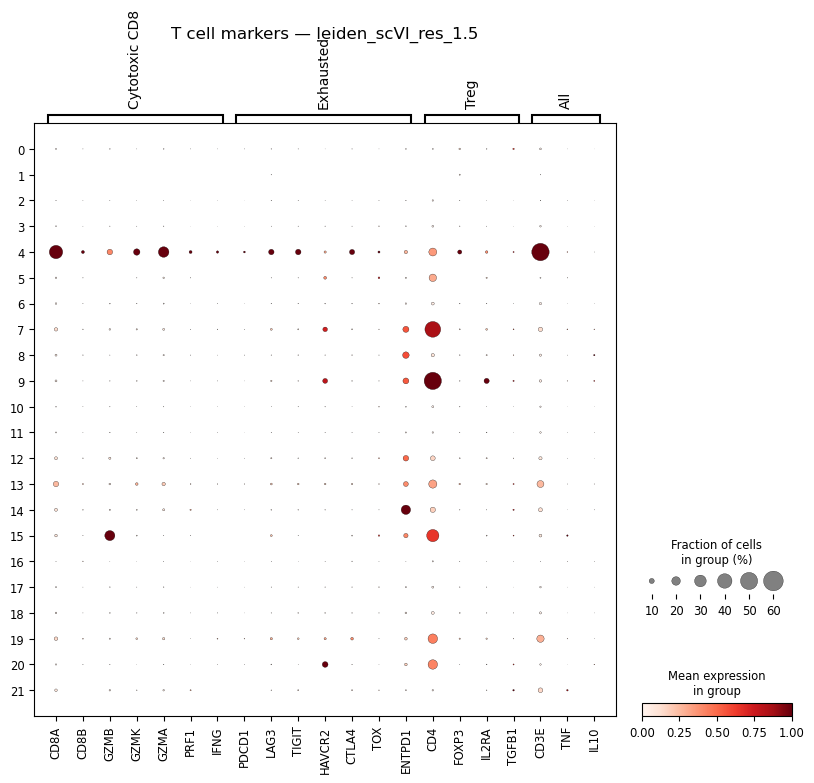


RESOLUTION: leiden_scVI_res_1

--- Top DE genes per cluster (log_norm) ---
Cluster 0: ['DSG1', 'LAD1', 'CXADR', 'ST14', 'NDRG1', 'GSDMC', 'JUP', 'GJA1', 'DSG3', 'SLC2A1', 'DMKN', 'CA12', 'GJB6', 'TMEM45A', 'SEMA4B']
Cluster 1: ['PSG1', 'DEFA1', 'HDC', 'ADRA1D', 'LGALS13', 'NODAL', 'IL17RB', 'OPN1LW', 'CACNG4', 'EIF5AL1', 'FOXB1', 'CASC8', 'TDGF1', 'FMN2', 'KLHL1']
Cluster 2: ['CD3E', 'CD8A', 'CD2', 'GZMA', 'IL2RG', 'CCND2', 'CD96', 'IKZF1', 'GIMAP4', 'ITGAL', 'SH2D1A', 'IKZF3', 'GPR174', 'KLRK1', 'LCK']
Cluster 3: ['CTSG', 'KIT', 'HPGD', 'MS4A2', 'GATA2', 'CMA1', 'SLC18A2', 'HDC', 'SIGLEC6', 'BTK', 'IL1RL1', 'ADCYAP1', 'HPGDS', 'BMP2K', 'CSF2RB']
Cluster 4: ['AKT2', 'TYMS', 'CDK2', 'STMN1', 'MME', 'BIRC5', 'BACE2', 'TUBB', 'ATP1A1', 'RAN', 'MCAM', 'LAPTM4B', 'CYCS', 'MLANA', 'ACTN4']
Cluster 5: ['CD14', 'CYBB', 'MRC1', 'ITGB2', 'CTSC', 'CD4', 'FCGR2A', 'MSR1', 'CD68', 'GRN', 'CD163', 'LIPA', 'SLCO2B1', 'LGMN', 'STAB1']
Cluster 6: ['POSTN', 'COL5A1', 'COL5A2', 'THY1', 'CXCL12', 'CTSK',

/tmp/ipykernel_2773824/3294693258.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores = adata.obs.groupby(groupby_key)[score_cols].mean()
/tmp/ipykernel_2773824/3294693258.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores['cell_count'] = adata.obs.groupby(groupby_key).size()



--- Marker set scores and cell counts per cluster (log_norm) ---
                   Cytotoxic_CD8_score  Exhausted_CD8_score  Treg_score  \
leiden_scVI_res_1                                                         
0                            -0.249599            -0.282031   -0.188773   
1                            -0.009181            -0.008500    0.007722   
2                             0.653032             0.486950    0.443437   
3                            -0.079633            -0.059268    0.011239   
4                            -0.248778            -0.267039   -0.199852   
5                            -0.045033            -0.004543    0.263954   
6                            -0.029278            -0.040489    0.042539   
7                            -0.219072            -0.231643   -0.169864   
8                            -0.108118            -0.116047   -0.083495   
9                            -0.036029            -0.021054    0.031014   
10                           -0.06

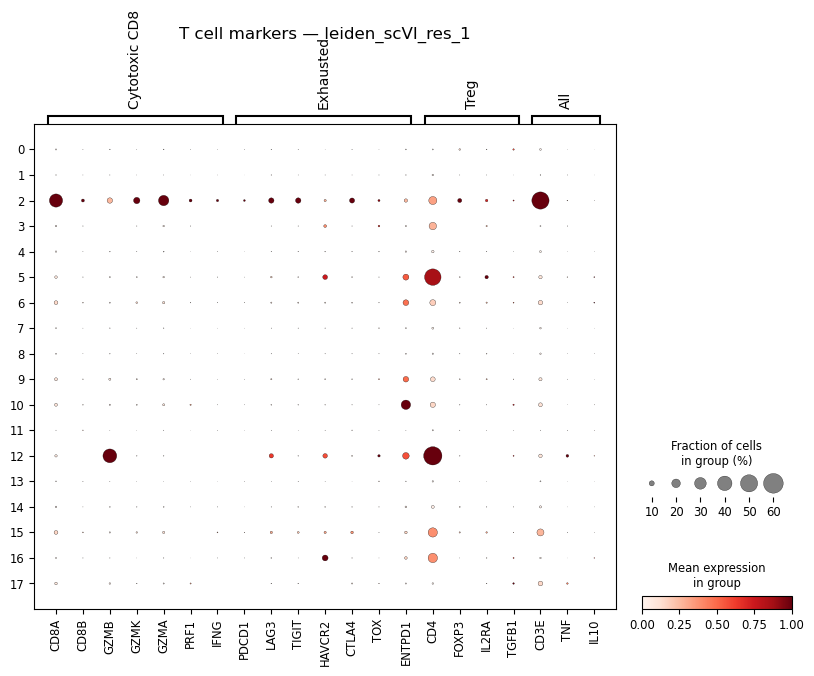


RESOLUTION: leiden_scVI_res_0.75

--- Top DE genes per cluster (log_norm) ---
Cluster 0: ['DSG1', 'LAD1', 'CXADR', 'ST14', 'NDRG1', 'GSDMC', 'JUP', 'GJA1', 'DSG3', 'SLC2A1', 'DMKN', 'CA12', 'GJB6', 'TMEM45A', 'SEMA4B']
Cluster 1: ['CLEC4C', 'LILRA4', 'IRF8', 'IL3RA', 'GUCY2D', 'PHEX', 'SPIB', 'SIGLEC6', 'TLR9', 'PSG1', 'DNASE1L3', 'TDGF1', 'KCNK10', 'HDC', 'KCNK17']
Cluster 2: ['CD3E', 'CD8A', 'CD2', 'GZMA', 'IL2RG', 'CCND2', 'CD96', 'IKZF1', 'GIMAP4', 'ITGAL', 'SH2D1A', 'IKZF3', 'KLRK1', 'GPR174', 'LCK']
Cluster 3: ['CTSG', 'KIT', 'HPGD', 'MS4A2', 'GATA2', 'CMA1', 'SLC18A2', 'HDC', 'SIGLEC6', 'BTK', 'IL1RL1', 'ADCYAP1', 'HPGDS', 'BMP2K', 'CSF2RB']
Cluster 4: ['S100A1', 'ADGRG1', 'ATP1A1', 'MLANA', 'FBL', 'CDK2', 'AKT2', 'ERBB3', 'PRAME', 'EDNRB', 'TFAP2A', 'CD59', 'LAPTM4B', 'MCAM', 'TDRD3']
Cluster 5: ['CD14', 'CYBB', 'ITGB2', 'MRC1', 'CTSC', 'CD4', 'FCGR2A', 'MSR1', 'CD68', 'GRN', 'CD163', 'LIPA', 'SLCO2B1', 'LGMN', 'STAB1']
Cluster 6: ['COL5A1', 'THY1', 'COL5A2', 'POSTN', 'CTSK', 

/tmp/ipykernel_2773824/3294693258.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores = adata.obs.groupby(groupby_key)[score_cols].mean()
/tmp/ipykernel_2773824/3294693258.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores['cell_count'] = adata.obs.groupby(groupby_key).size()



--- Marker set scores and cell counts per cluster (log_norm) ---
                      Cytotoxic_CD8_score  Exhausted_CD8_score  Treg_score  \
leiden_scVI_res_0.75                                                         
0                               -0.249708            -0.282153   -0.188857   
1                               -0.001082            -0.001610    0.015558   
2                                0.651541             0.485033    0.441130   
3                               -0.079633            -0.059268    0.011239   
4                               -0.225685            -0.239583   -0.176599   
5                               -0.044595            -0.003742    0.262967   
6                               -0.106048            -0.095674   -0.024550   
7                               -0.120361            -0.128446   -0.094252   
8                               -0.036834            -0.021473    0.029846   
9                               -0.070647            -0.034394    0.056758  

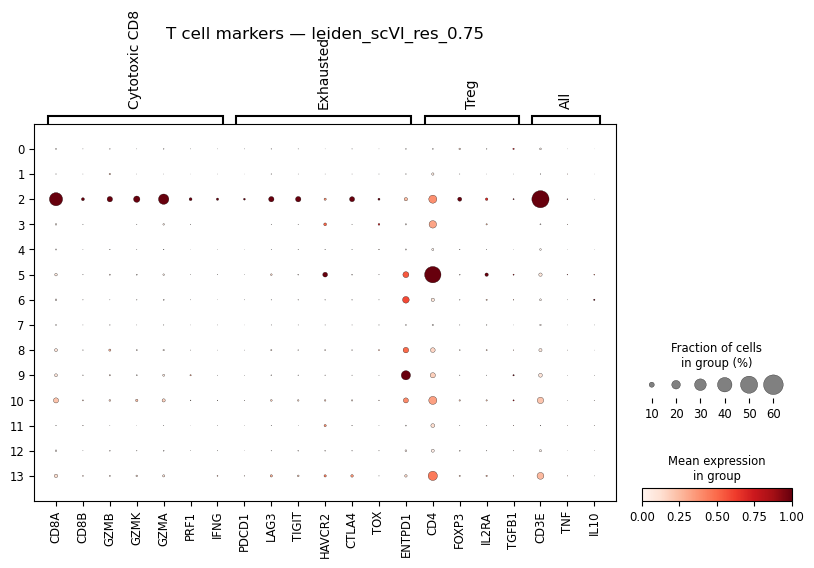


RESOLUTION: leiden_scVI_res_0.65

--- Top DE genes per cluster (log_norm) ---
Cluster 0: ['DSG1', 'LAD1', 'CXADR', 'ST14', 'NDRG1', 'GSDMC', 'JUP', 'GJA1', 'DSG3', 'SLC2A1', 'DMKN', 'CA12', 'GJB6', 'TMEM45A', 'SEMA4B']
Cluster 1: ['CD14', 'MRC1', 'CYBB', 'ITGB2', 'CTSC', 'CD4', 'FCGR2A', 'MSR1', 'CD68', 'CD163', 'SLCO2B1', 'STAB1', 'LIPA', 'GRN', 'SIGLEC1']
Cluster 2: ['CD3E', 'CD8A', 'POSTN', 'CD2', 'GZMA', 'IL2RG', 'CCND2', 'GIMAP4', 'CD96', 'CXCL9', 'IKZF1', 'COL5A1', 'CXCL12', 'ITGAL', 'SULF1']
Cluster 3: ['CTSG', 'KIT', 'HPGD', 'MS4A2', 'GATA2', 'CMA1', 'SLC18A2', 'HDC', 'SIGLEC6', 'BTK', 'IL1RL1', 'ADCYAP1', 'HPGDS', 'BMP2K', 'CSF2RB']
Cluster 4: ['S100A1', 'ADGRG1', 'ATP1A1', 'MLANA', 'FBL', 'AKT2', 'CDK2', 'ERBB3', 'PRAME', 'EDNRB', 'TFAP2A', 'CD59', 'LAPTM4B', 'RASSF3', 'MCAM']
Cluster 5: ['COL5A1', 'COL5A2', 'THY1', 'POSTN', 'CTSK', 'CCDC80', 'COMP', 'THBS1', 'HIF1A', 'IL6', 'FMOD', 'AEBP1', 'MRC2', 'CXCL12', 'FSTL1']
Cluster 6: ['S100A1', 'HOXB7', 'VGF', 'MME', 'FBL', 'LDHA

/tmp/ipykernel_2773824/3294693258.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores = adata.obs.groupby(groupby_key)[score_cols].mean()
/tmp/ipykernel_2773824/3294693258.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores['cell_count'] = adata.obs.groupby(groupby_key).size()



--- Marker set scores and cell counts per cluster (log_norm) ---
                      Cytotoxic_CD8_score  Exhausted_CD8_score  Treg_score  \
leiden_scVI_res_0.65                                                         
0                               -0.249726            -0.282188   -0.188885   
1                               -0.040298            -0.005263    0.219782   
2                                0.491489             0.360923    0.352666   
3                               -0.079413            -0.058984    0.010891   
4                               -0.224208            -0.238087   -0.175102   
5                               -0.107607            -0.097240   -0.025637   
6                               -0.120327            -0.128209   -0.094216   
7                               -0.036960            -0.021598    0.030758   
8                               -0.071719            -0.035043    0.056285   
9                               -0.019371            -0.007330    0.023389  

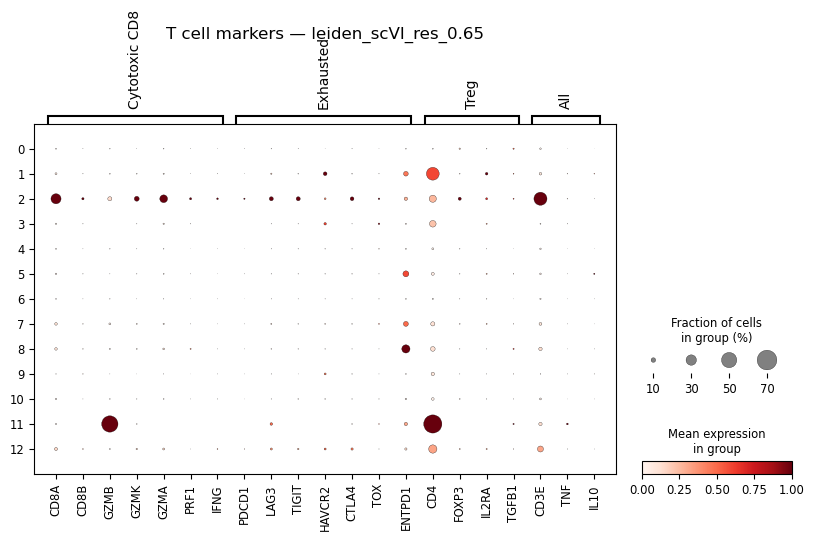


RESOLUTION: leiden_scVI_res_0.5

--- Top DE genes per cluster (log_norm) ---
Cluster 0: ['S100A1', 'ADGRG1', 'ATP1A1', 'MLANA', 'FBL', 'CDK2', 'AKT2', 'PRAME', 'ERBB3', 'EDNRB', 'TFAP2A', 'TDRD3', 'RASSF3', 'CD59', 'LAPTM4B']
Cluster 1: ['CD3E', 'CD8A', 'POSTN', 'CD2', 'GZMA', 'IL2RG', 'CXCL9', 'CCND2', 'GIMAP4', 'CD96', 'IKZF1', 'COL5A1', 'CXCL12', 'ITGAL', 'SULF1']
Cluster 2: ['ITGB2', 'CD14', 'CYBB', 'MRC1', 'CD4', 'CTSC', 'FCGR2A', 'MSR1', 'CD68', 'CD163', 'LIPA', 'GRN', 'SLCO2B1', 'STAB1', 'SIGLEC1']
Cluster 3: ['S100A1', 'HOXB7', 'VGF', 'MME', 'FBL', 'PAEP', 'L1CAM', 'LDHA', 'YWHAZ', 'ATP1A1', 'ADGRG1', 'PRAME', 'BIRC7', 'CD44', 'MLANA']
Cluster 4: ['COL4A1', 'COL4A2', 'EPAS1', 'PLVAP', 'MYH9', 'THY1', 'COL18A1', 'PECAM1', 'APP', 'SERPINH1', 'CD34', 'HSPG2', 'ENG', 'PDGFRB', 'TFPI']
Cluster 5: ['SOX2-OT', 'SOST', 'ALG11', 'DUX4', 'ADRB1', 'OSGIN1', 'F7', 'POTEI', 'POTEF', 'PGA3', 'EIF5AL1', 'SULT1A1', 'TDGF1', 'DRD5', 'LGALS13']
Cluster 6: ['COL5A1', 'COL5A2', 'THY1', 'POSTN', '

/tmp/ipykernel_2773824/3294693258.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores = adata.obs.groupby(groupby_key)[score_cols].mean()
/tmp/ipykernel_2773824/3294693258.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_scores['cell_count'] = adata.obs.groupby(groupby_key).size()



--- Marker set scores and cell counts per cluster (log_norm) ---
                     Cytotoxic_CD8_score  Exhausted_CD8_score  Treg_score  \
leiden_scVI_res_0.5                                                         
0                              -0.220587            -0.234091   -0.171861   
1                               0.477736             0.350568    0.346994   
2                              -0.048053            -0.009661    0.208492   
3                              -0.106796            -0.114448   -0.081171   
4                              -0.074792            -0.037267    0.053553   
5                              -0.004185            -0.002752    0.006902   
6                              -0.110005            -0.099389   -0.030221   
7                              -0.237058            -0.256644   -0.188895   
8                              -0.038658            -0.023204    0.028025   
9                              -0.249338            -0.281747   -0.188627   
10        

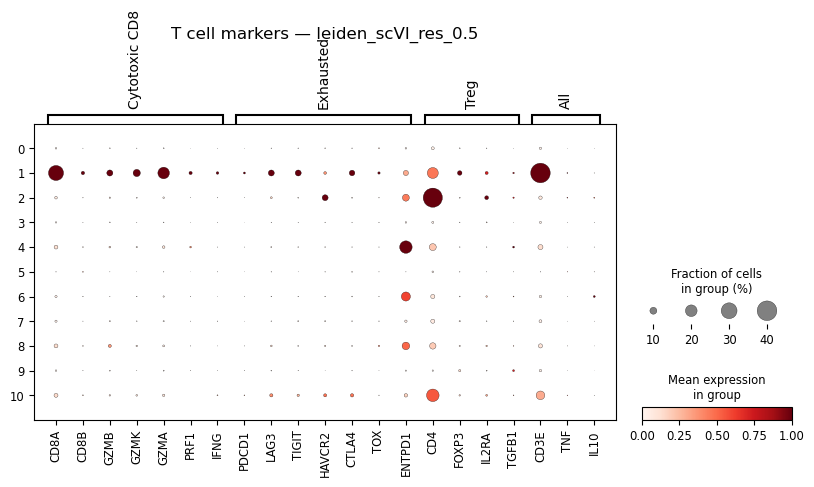

In [8]:
marker_sets = {
    'Cytotoxic_CD8': ['CD8A', 'CD8B', 'CD3D', 'CD3E', 'GZMB', 'GZMK', 'GZMA', 'PRF1', 'IFNG', 'TNF'],
    'Exhausted_CD8': ['CD8A', 'CD8B', 'CD3D', 'CD3E', 'GZMB', 'GZMK', 'PDCD1', 'LAG3', 'TIGIT', 'HAVCR2', 'CTLA4', 'TOX', 'ENTPD1'],
    'Treg': ['CD4', 'CD3D', 'CD3E', 'FOXP3', 'IL2RA', 'CTLA4', 'IL10', 'TGFB1', 'ENTPD1'],
}

marker_genes_dotplot = {
    'Cytotoxic CD8': ['CD8A', 'CD8B', 'GZMB', 'GZMK', 'GZMA', 'PRF1', 'IFNG'],
    'Exhausted': ['PDCD1', 'LAG3', 'TIGIT', 'HAVCR2', 'CTLA4', 'TOX', 'ENTPD1'],
    'Treg': ['CD4', 'FOXP3', 'IL2RA', 'TGFB1'],
    'All': ['CD3D', 'CD3E', 'TNF', 'IL10'],
}


def annotate_clusters(adata, groupby_key, n_top_genes=15, de_genes_dict=None):
    print(f"\n{'='*60}")
    print(f"RESOLUTION: {groupby_key}")
    print(f"{'='*60}")
    
    # --- Approach 1: top DE genes per cluster (on log_norm) ---
    sc.tl.rank_genes_groups(
        adata,
        groupby=groupby_key,
        method='wilcoxon',
        layer='log_norm',
        use_raw=False
    )
    result = adata.uns['rank_genes_groups']
    groups = result['names'].dtype.names
    
    # Initialize dictionary for this resolution if provided
    if de_genes_dict is not None:
        de_genes_dict[groupby_key] = {}
    
    print("\n--- Top DE genes per cluster (log_norm) ---")
    for group in groups:
        top_genes = result['names'][group][:n_top_genes]
        print(f"Cluster {group}: {list(top_genes)}")
        # Save DE genes to the dictionary
        if de_genes_dict is not None:
            de_genes_dict[groupby_key][group] = list(top_genes)
    
    # --- Approach 2: marker set scores per cluster (on log_norm) ---
    for name, genes in marker_sets.items():
        genes_present = [g for g in genes if g in adata.var_names]
        sc.tl.score_genes(
            adata,
            gene_list=genes_present,
            score_name=f'{name}_score',
            layer='log_norm'
        )
    
    score_cols = [f'{name}_score' for name in marker_sets.keys()]

    # 1. Calculate the mean scores per cluster
    cluster_scores = adata.obs.groupby(groupby_key)[score_cols].mean()
    # 2. Calculate the cell count per cluster and add it as a new column
    cluster_scores['cell_count'] = adata.obs.groupby(groupby_key).size()
    print("\n--- Marker set scores and cell counts per cluster (log_norm) ---")
    print(cluster_scores)
    
    # --- Approach 3: dot plot (on log_norm) ---
    marker_genes_filt = {
        group: [g for g in genes if g in adata.var_names]
        for group, genes in marker_genes_dotplot.items()
    }
    sc.pl.dotplot(
        adata,
        var_names=marker_genes_filt,
        groupby=groupby_key,
        layer='log_norm',
        standard_scale='var',
        title=f'T cell markers — {groupby_key}'
    )
    
    return cluster_scores

# Initialize the dictionary and run the loop
de_genes_dict = {}
all_scores = {}
for res_key in res_labels:
    all_scores[res_key] = annotate_clusters(adata, res_key, de_genes_dict=de_genes_dict)

In [9]:
all_scores[res_label(0.75)]

,Cytotoxic_CD8_score,Exhausted_CD8_score,Treg_score,cell_count
leiden_scVI_res_0.75,,,,
0,-0.249708,-0.282153,-0.188857,3128
1,-0.001082,-0.001610,0.015558,3410
2,0.651541,0.485033,0.441130,14947
3,-0.079633,-0.059268,0.011239,242
4,-0.225685,-0.239583,-0.176599,35913
5,-0.044595,-0.003742,0.262967,15613
6,-0.106048,-0.095674,-0.024550,4618
7,-0.120361,-0.128446,-0.094252,7719
8,-0.036834,-0.021473,0.029846,3941


/tmp/ipykernel_2773824/2858284378.py:8: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, spot_size=5, show=False, title=DATASET_NAME, color='t_cell');


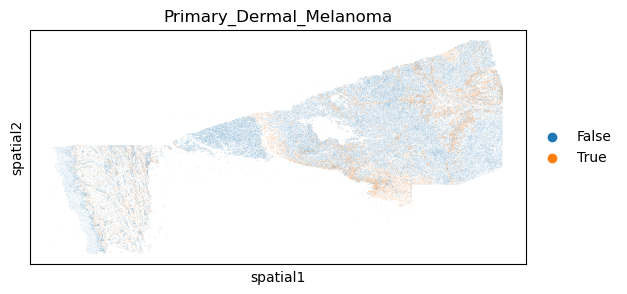

In [10]:
res = 0.75
cd8 = ['2'] #CD8
cd4 = ['5'] #CD4
t_cell_clusts = list(set(cd8 + cd4))
adata.obs['cd8'] = adata.obs[res_label(res)].isin(cd8) 
adata.obs['cd4'] = adata.obs[res_label(res)].isin(cd4)
adata.obs['t_cell'] = adata.obs[res_label(res)].isin(t_cell_clusts) 
sc.pl.spatial(adata, spot_size=5, show=False, title=DATASET_NAME, color='t_cell');

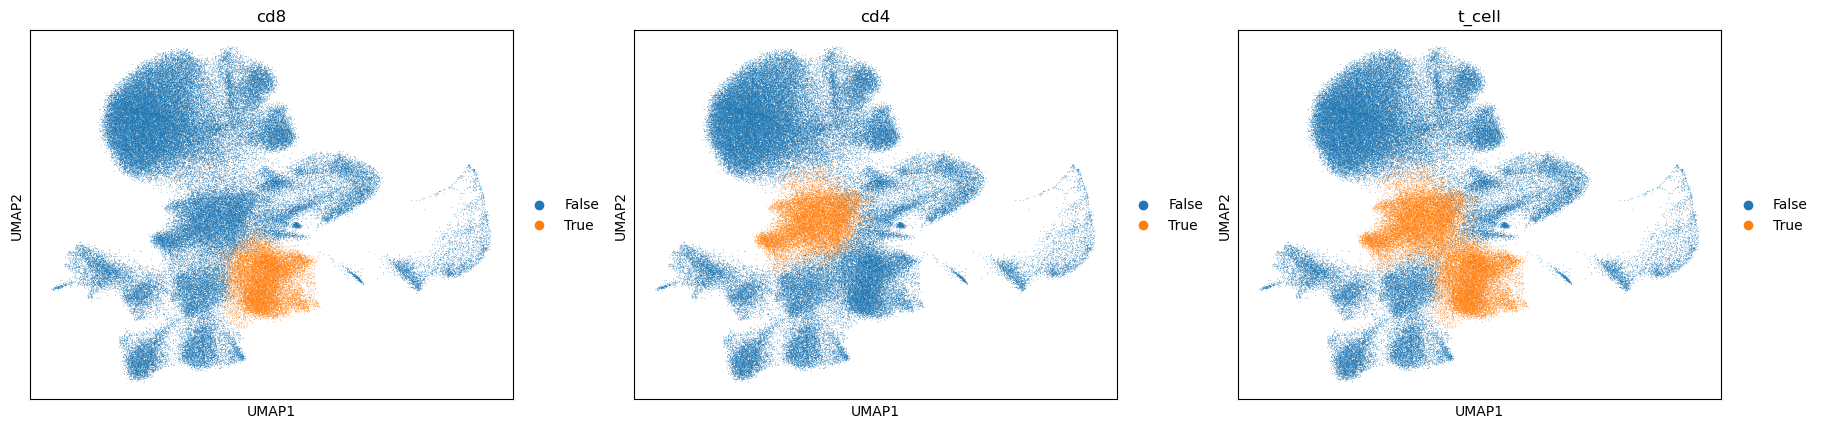

In [11]:
sc.pl.umap(adata, color=['cd8', 'cd4', 't_cell'])

In [12]:
print(f'Not t cell: {sum(~adata.obs['t_cell'])}')
print(f't cell: {sum(adata.obs['t_cell'])}')
print(f'cd8: {sum(adata.obs['cd8'])}')
print(f'cd4: {sum(adata.obs['cd4'])}')

Not t cell: 81991
t cell: 30560
cd8: 14947
cd4: 15613


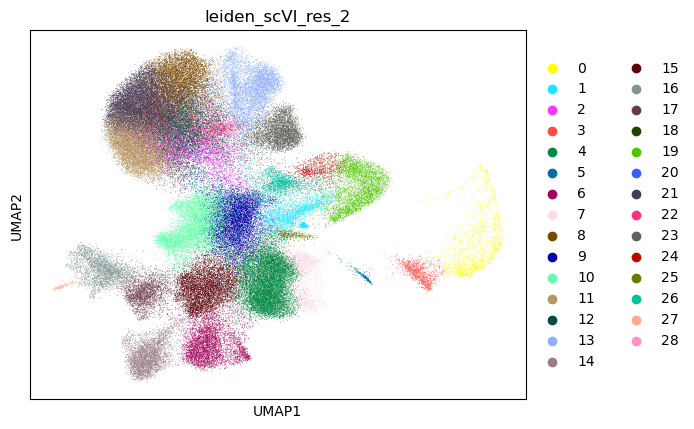

In [13]:
sc.pl.umap(adata, color=[res_label(2)])

In [14]:
def sub_res_label(res, clusters):
    """Order of clusters does not matter"""
    return f'sub_cluster_{"-".join(sorted(clusters))}_res_{res}'

def subcluster(adata, clusters, sub_res, clusters_res_label, de_genes_dict=None):
    print(f'Starting Sub Resolutions {sub_res}')
    new_col_name = sub_res_label(sub_res, clusters)

    # 2. Filter the adata to include only the targeted clusters
    subset_mask = adata.obs[clusters_res_label].isin(clusters)
    adata_sub = adata[subset_mask].copy()

    if new_col_name in adata.obs:
        print(f'{new_col_name} already in adata, skipping')
        # Re-load the existing labels into the subset for DE calculation
        adata_sub.obs[new_col_name] = adata.obs.loc[subset_mask, new_col_name].values
    else:
        # 3. Run the Leiden clustering on the subset
        sc.tl.leiden(adata_sub, resolution=sub_res, key_added=new_col_name, flavor='igraph')
        
        # 4. Initialize the new column in the original adata with "other"
        adata.obs[new_col_name] = "other"
        
        # 5. Map the subset's new cluster results back to the original adata
        adata.obs.loc[subset_mask, new_col_name] = adata_sub.obs[new_col_name].astype(str)
        adata.obs[new_col_name] = adata.obs[new_col_name].astype('category')
    
    # Dot plot base setup
    marker_genes_filt = {
        group: [g for g in genes if g in adata.var_names]
        for group, genes in marker_genes_dotplot.items()
    }
    
    # Compute top DE genes for each new subcluster
    sc.tl.rank_genes_groups(
        adata_sub,
        groupby=new_col_name,
        method='wilcoxon',
        layer='log_norm',
        use_raw=False
    )
    result = adata_sub.uns['rank_genes_groups']
    sub_groups = result['names'].dtype.names
    
    # Add top 10 DE genes per subcluster to the dotplot
    for group in sub_groups:
        top_sub_genes = result['names'][group][:10]
        marker_genes_filt[f'Subcluster {group} Top DE'] = [g for g in top_sub_genes if g in adata.var_names]

    sc.pl.dotplot(
        adata,
        var_names=marker_genes_filt,
        groupby=new_col_name,
        layer='log_norm',
        standard_scale='var',
        title=f'T cell markers & Subcluster DE — {new_col_name}'
    )

    print(f"\nSub-cluster sizes for {new_col_name}:")
    print(adata.obs[new_col_name].value_counts())
    
    return adata

In [15]:
sub_resolutions = [1, 0.75, 0.5, 0.37, 0.25, 0.15, 0.1, 0.05]

Starting Sub Resolutions 1


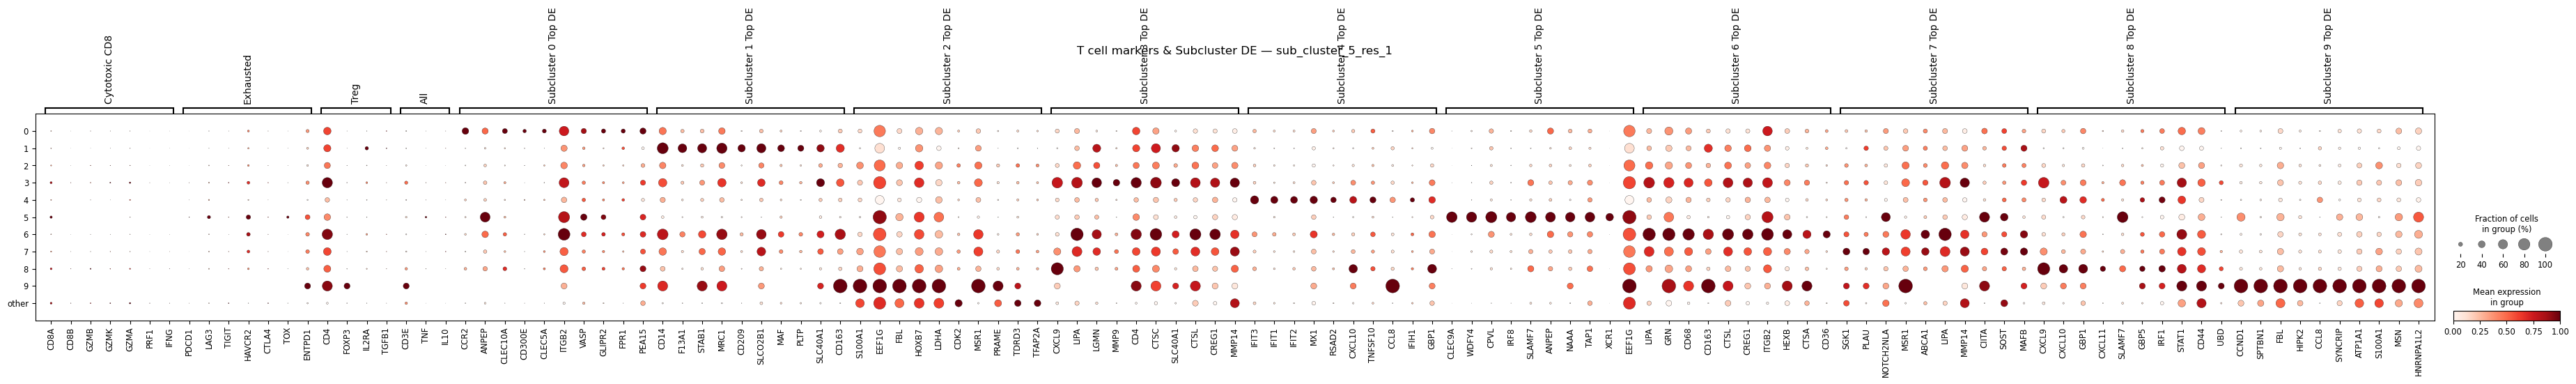


Sub-cluster sizes for sub_cluster_5_res_1:
sub_cluster_5_res_1
other    96938
8         3106
1         2860
0         2205
7         2107
2         2053
6         2026
3          948
4          242
5           63
9            3
Name: count, dtype: int64
Starting Sub Resolutions 0.75


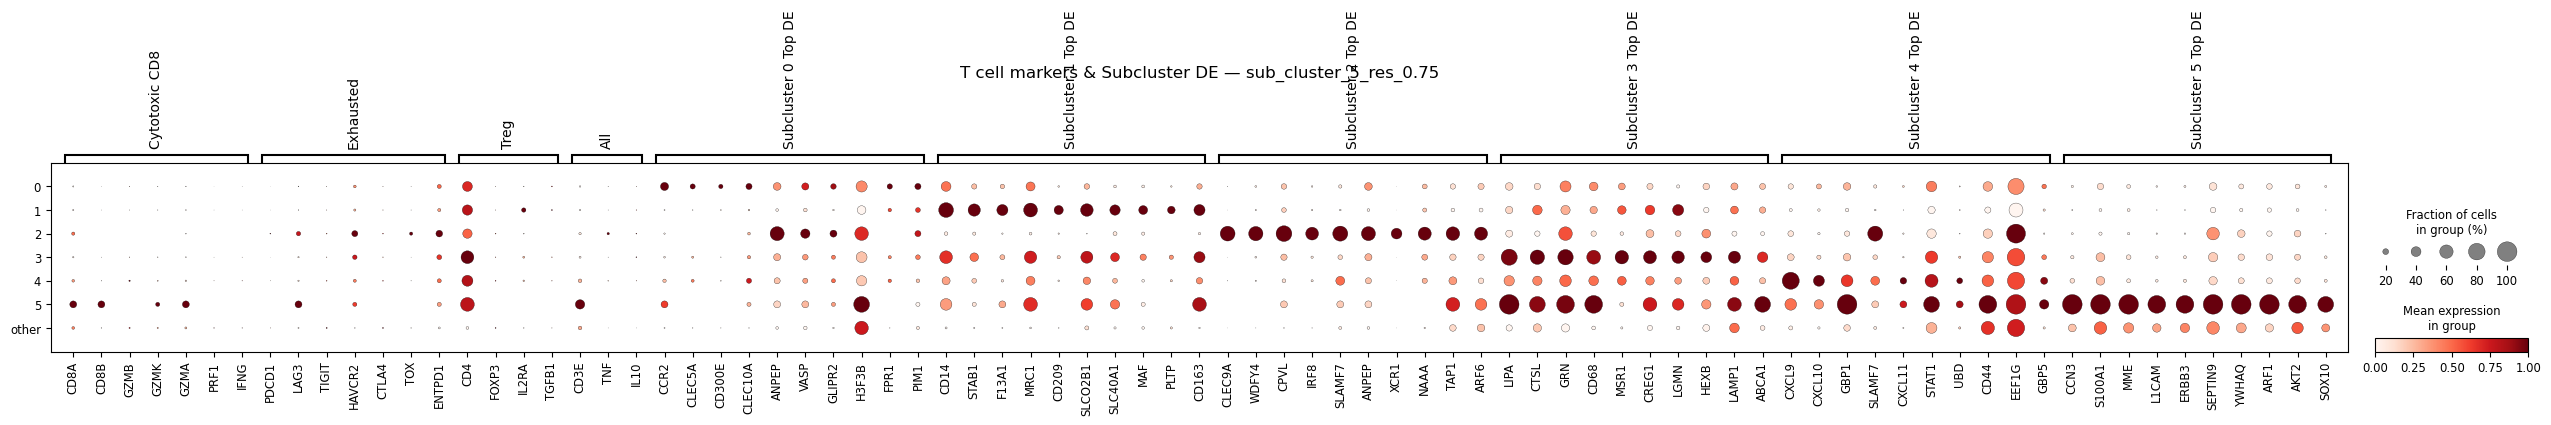


Sub-cluster sizes for sub_cluster_5_res_0.75:
sub_cluster_5_res_0.75
other    96938
3         4540
4         4433
1         3764
0         2801
2           67
5            8
Name: count, dtype: int64
Starting Sub Resolutions 0.5


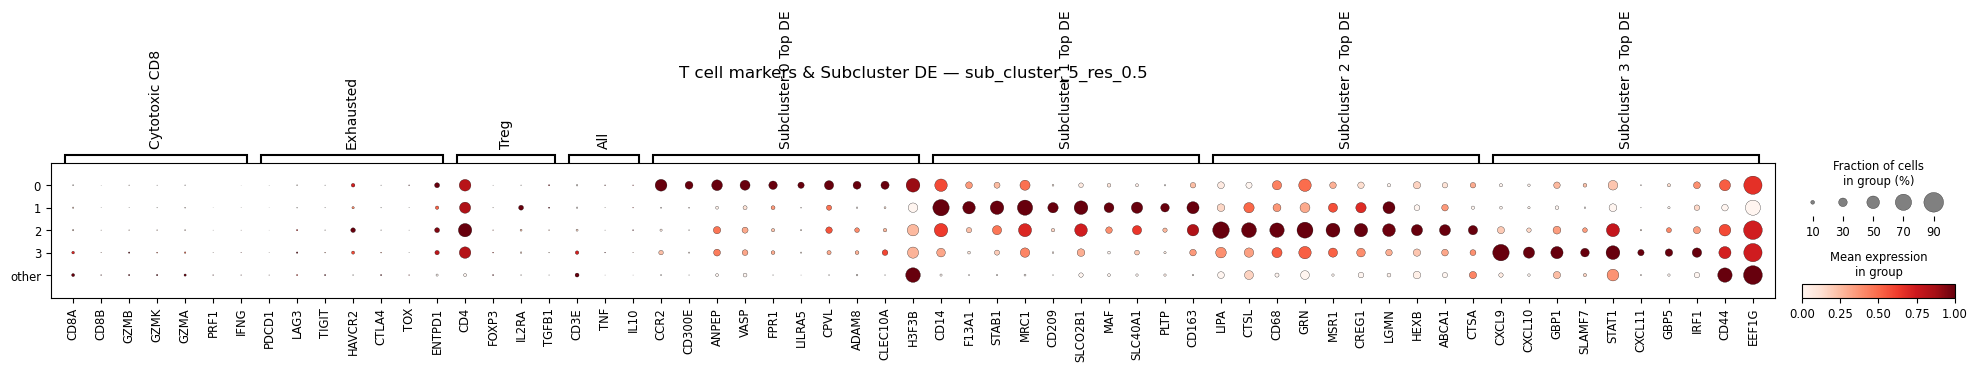


Sub-cluster sizes for sub_cluster_5_res_0.5:
sub_cluster_5_res_0.5
other    96938
3         5710
2         5320
1         3505
0         1078
Name: count, dtype: int64
Starting Sub Resolutions 0.37


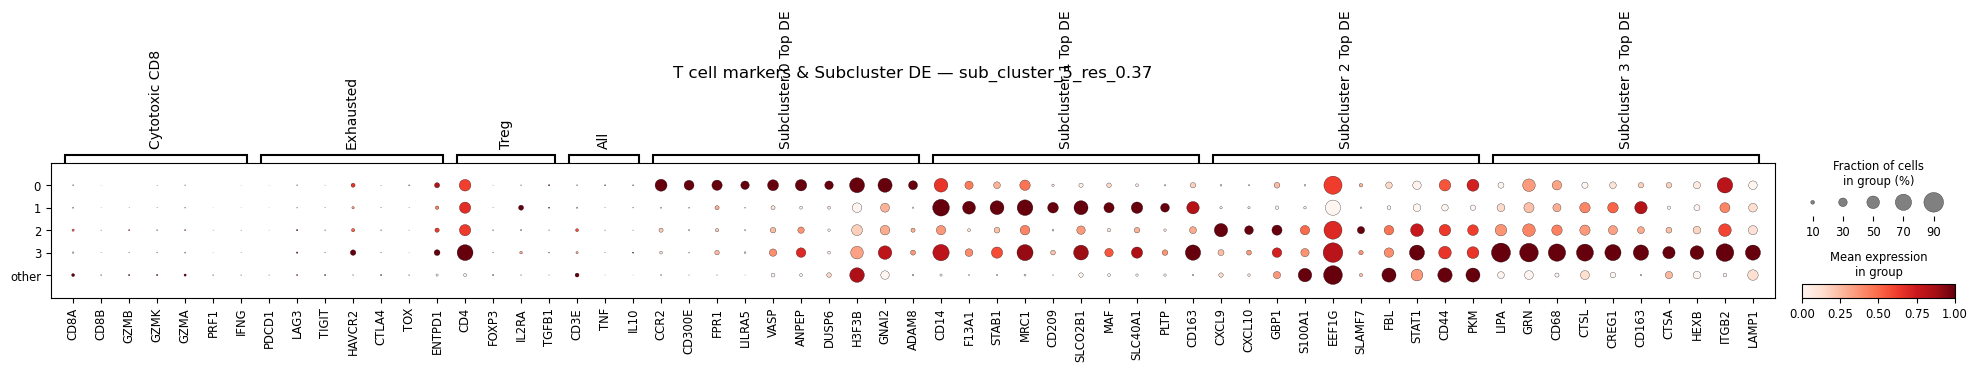


Sub-cluster sizes for sub_cluster_5_res_0.37:
sub_cluster_5_res_0.37
other    96938
2         9148
1         3323
3         2530
0          612
Name: count, dtype: int64
Starting Sub Resolutions 0.25


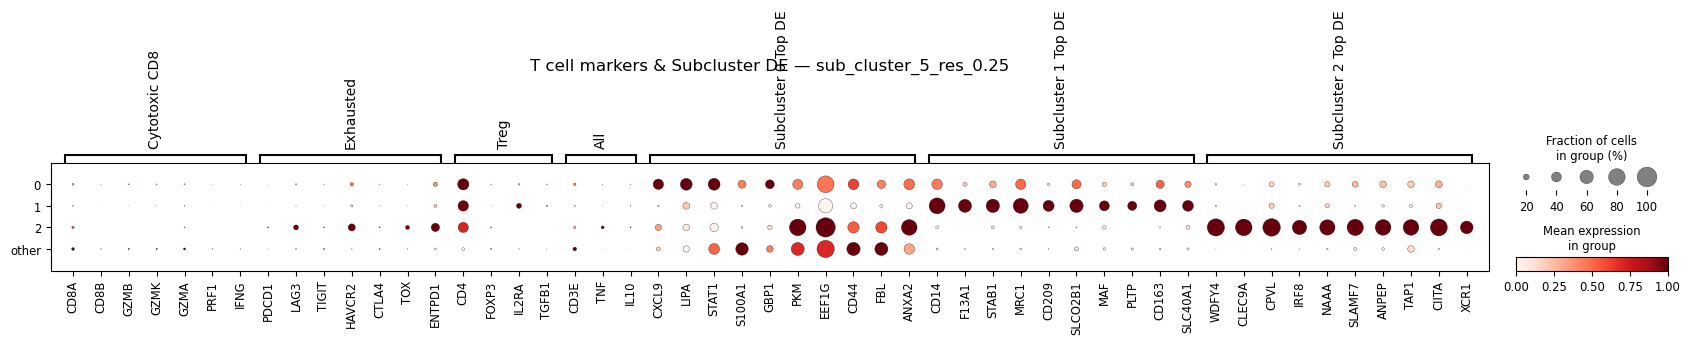


Sub-cluster sizes for sub_cluster_5_res_0.25:
sub_cluster_5_res_0.25
other    96938
0        12875
1         2688
2           50
Name: count, dtype: int64
Starting Sub Resolutions 0.15


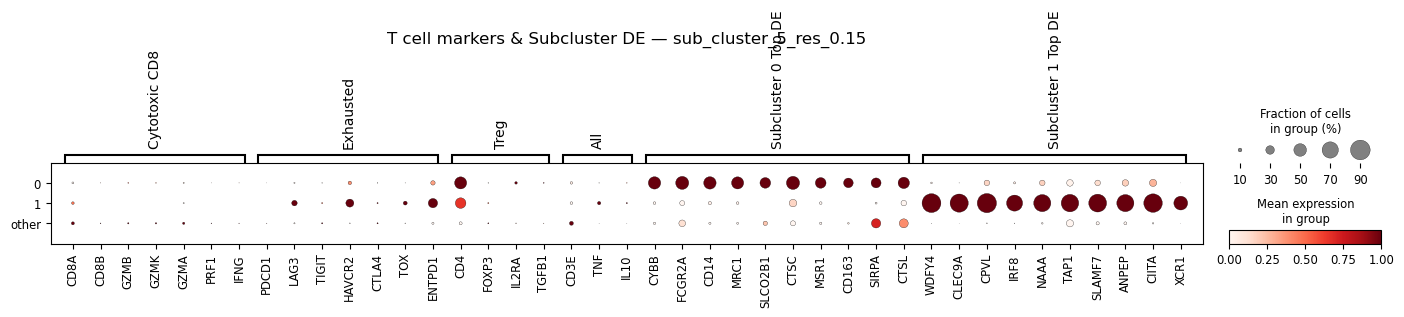


Sub-cluster sizes for sub_cluster_5_res_0.15:
sub_cluster_5_res_0.15
other    96938
0        15565
1           48
Name: count, dtype: int64
Starting Sub Resolutions 0.1


/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:380: RuntimeWarning: invalid value encountered in divide
  scores[group_index, :] = (


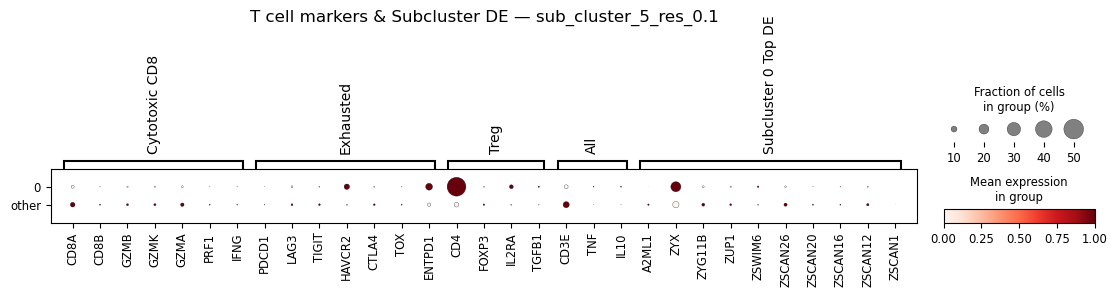


Sub-cluster sizes for sub_cluster_5_res_0.1:
sub_cluster_5_res_0.1
other    96938
0        15613
Name: count, dtype: int64
Starting Sub Resolutions 0.05


/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:380: RuntimeWarning: invalid value encountered in divide
  scores[group_index, :] = (


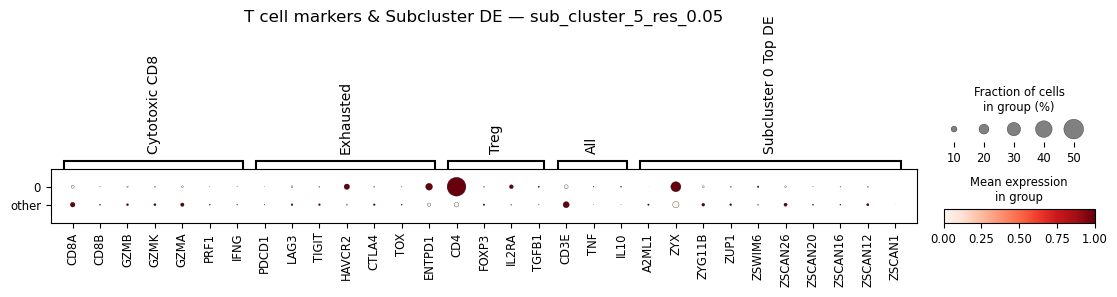


Sub-cluster sizes for sub_cluster_5_res_0.05:
sub_cluster_5_res_0.05
other    96938
0        15613
Name: count, dtype: int64


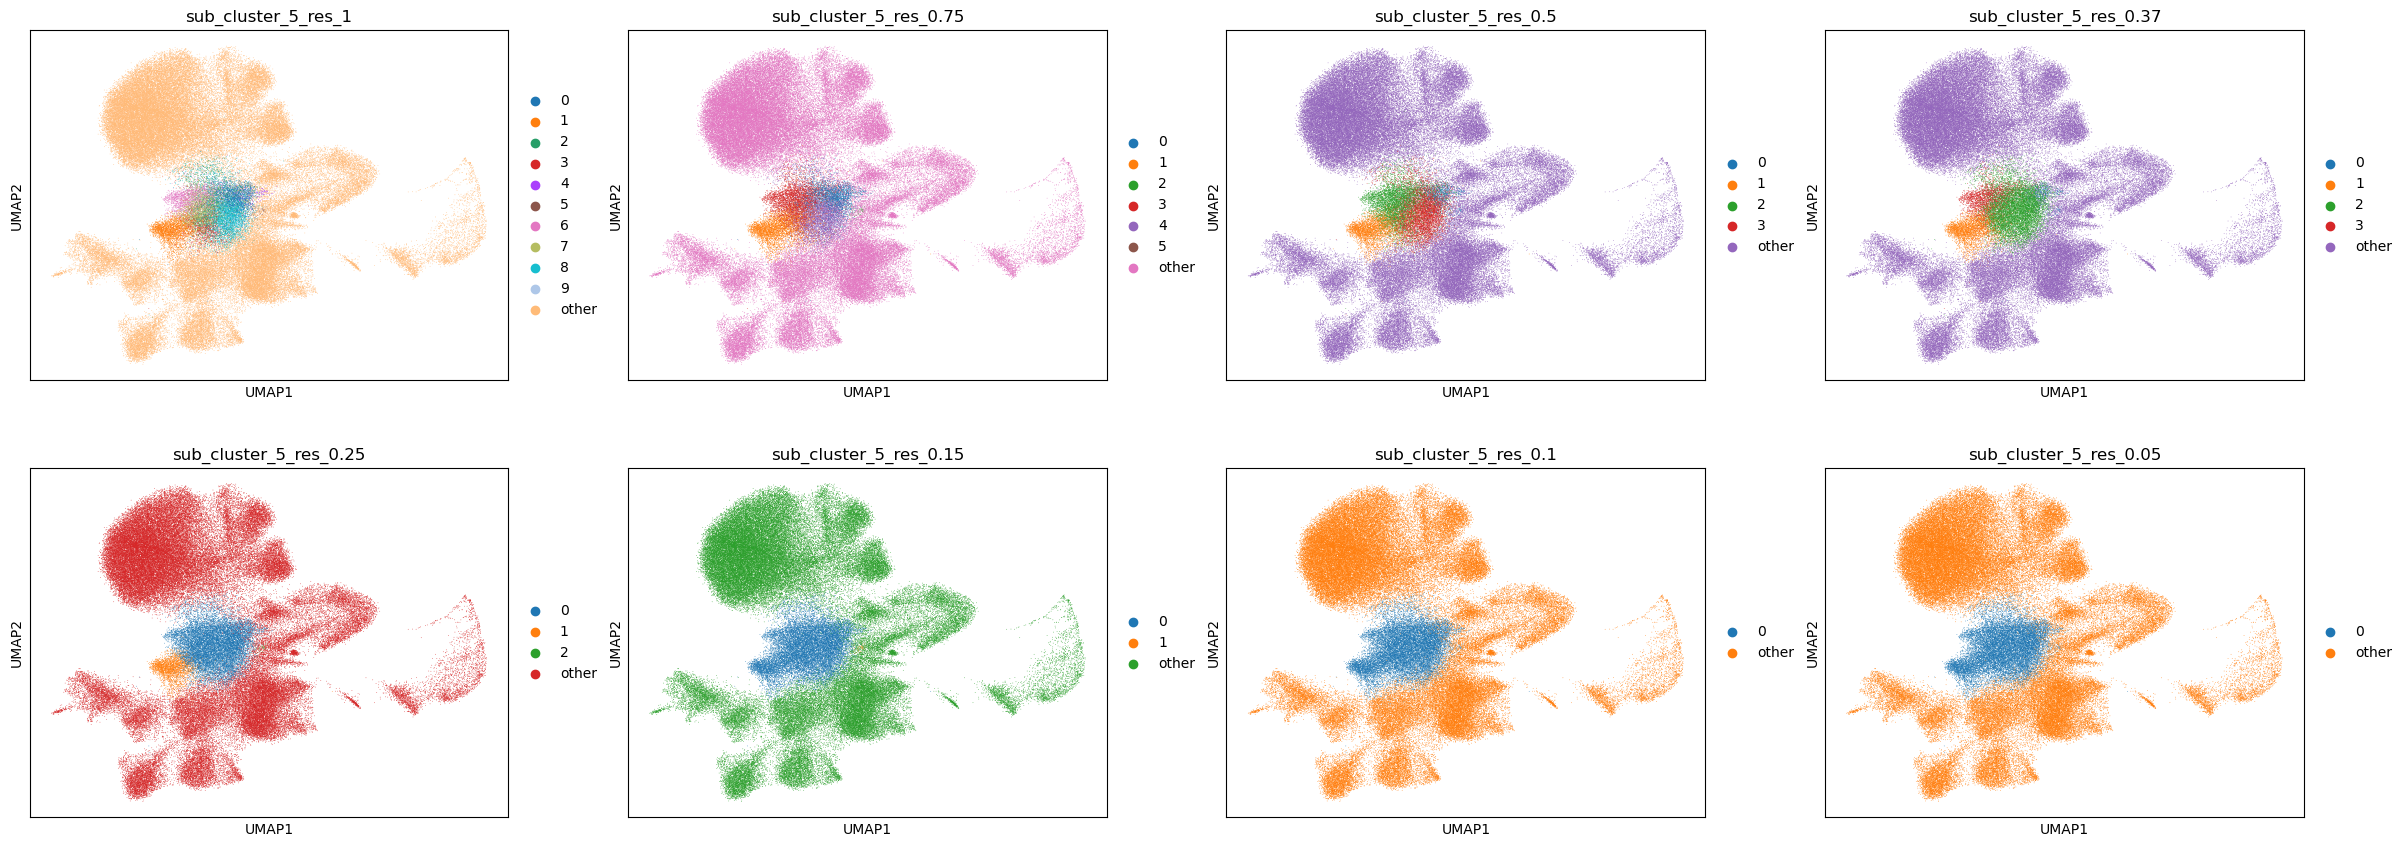

In [16]:
for sub_res in sub_resolutions:
    subcluster(adata, cd4, sub_res, clusters_res_label=res_label(res), de_genes_dict=de_genes_dict)
sc.pl.umap(adata, color=[sub_res_label(sub_res, cd4) for sub_res in sub_resolutions])

starting cd8
Starting Sub Resolutions 1


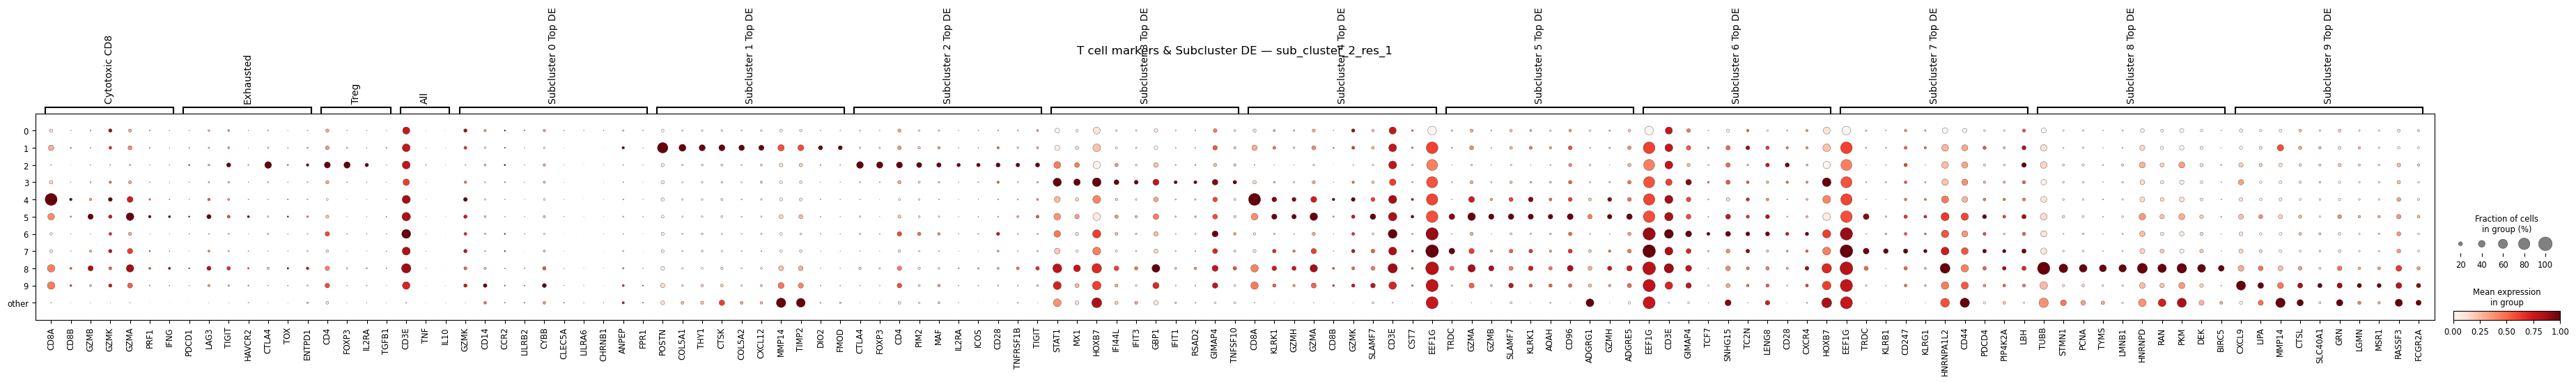


Sub-cluster sizes for sub_cluster_2_res_1:
sub_cluster_2_res_1
other    97604
4         3140
2         2194
6         1881
5         1789
8         1636
3         1378
0          971
1          781
7          642
9          535
Name: count, dtype: int64
Starting Sub Resolutions 0.75


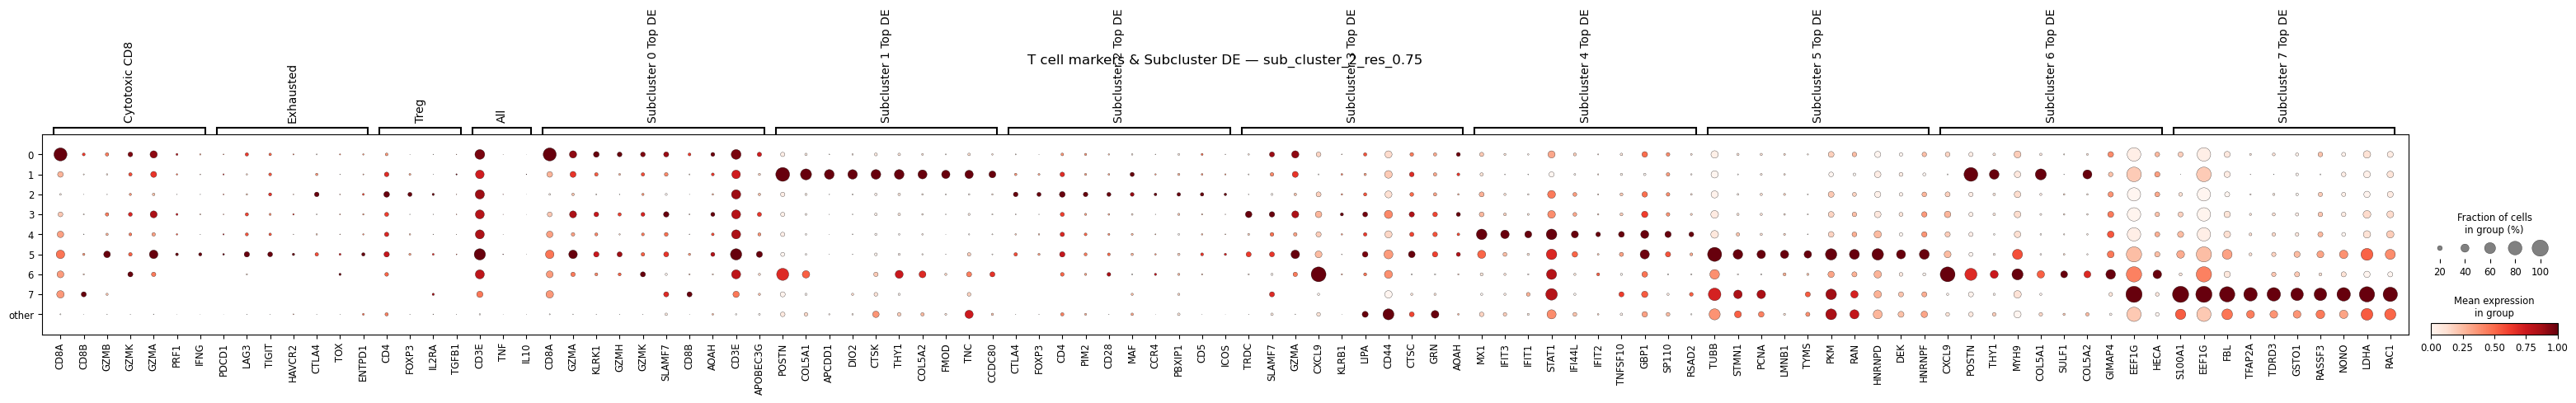


Sub-cluster sizes for sub_cluster_2_res_0.75:
sub_cluster_2_res_0.75
other    97604
2         5391
0         4715
3         2417
5         1993
4          239
1          150
6           28
7           14
Name: count, dtype: int64
Starting Sub Resolutions 0.5


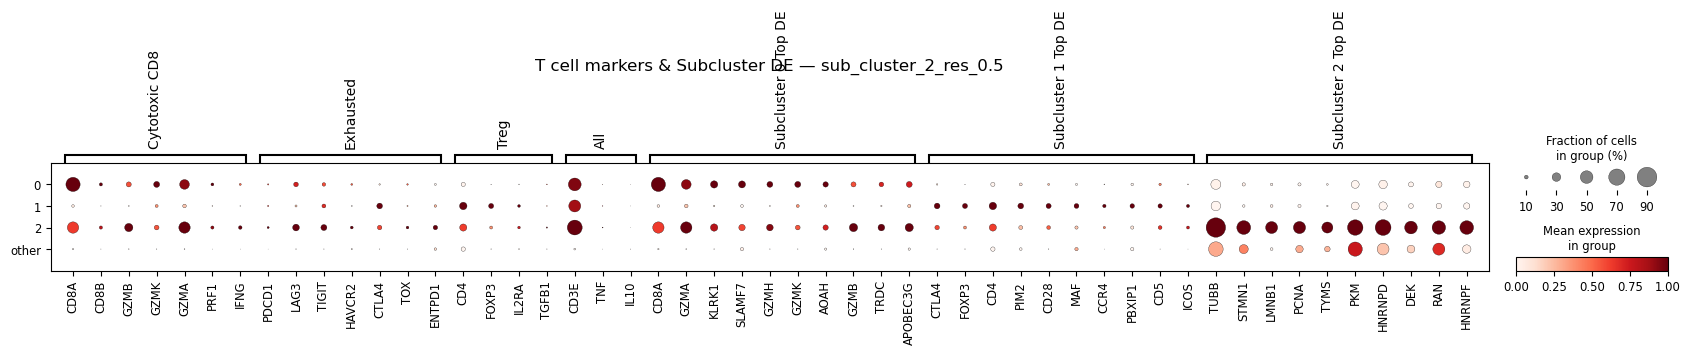


Sub-cluster sizes for sub_cluster_2_res_0.5:
sub_cluster_2_res_0.5
other    97604
0         7185
1         6171
2         1591
Name: count, dtype: int64
Starting Sub Resolutions 0.37


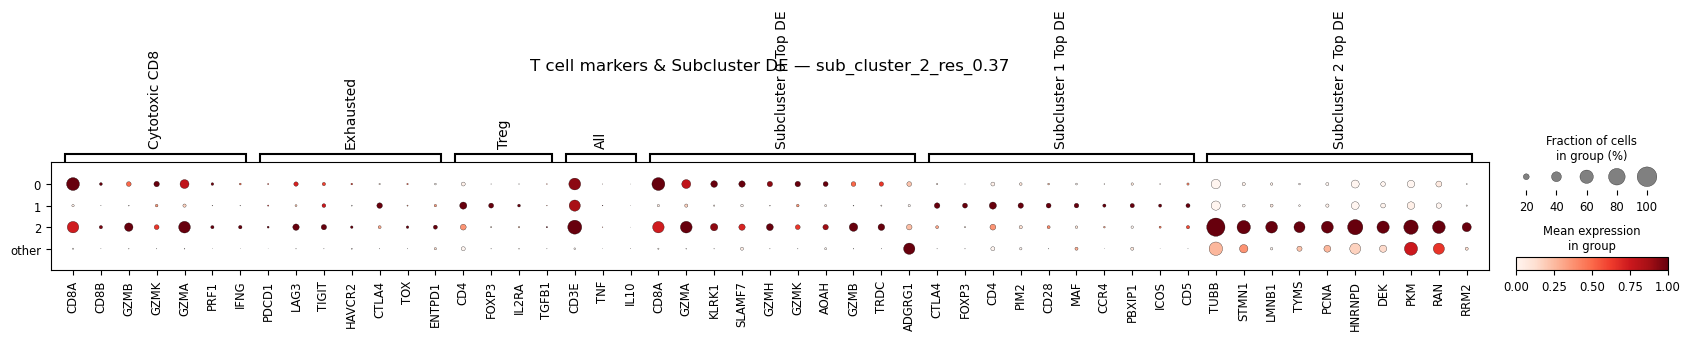


Sub-cluster sizes for sub_cluster_2_res_0.37:
sub_cluster_2_res_0.37
other    97604
0         7608
1         6172
2         1167
Name: count, dtype: int64
Starting Sub Resolutions 0.25


/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:380: RuntimeWarning: invalid value encountered in divide
  scores[group_index, :] = (


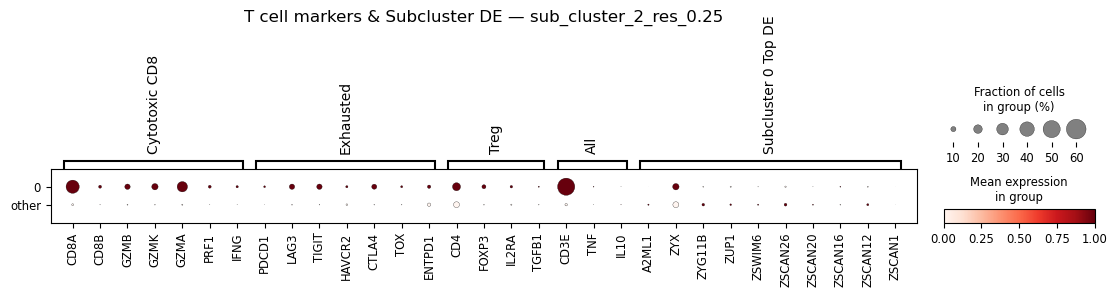


Sub-cluster sizes for sub_cluster_2_res_0.25:
sub_cluster_2_res_0.25
other    97604
0        14947
Name: count, dtype: int64
Starting Sub Resolutions 0.15


/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:380: RuntimeWarning: invalid value encountered in divide
  scores[group_index, :] = (


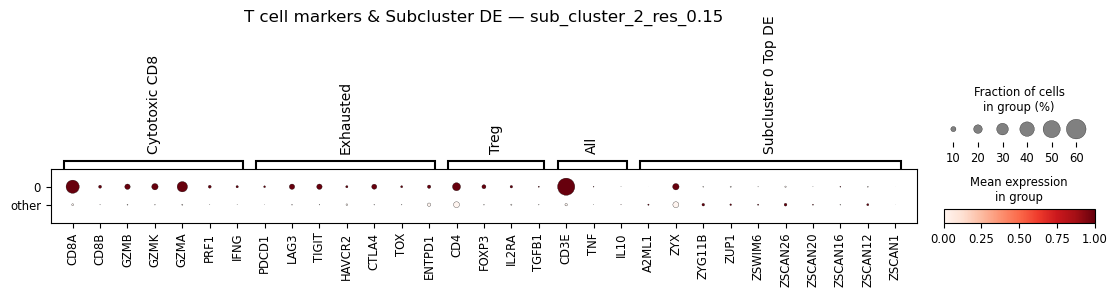


Sub-cluster sizes for sub_cluster_2_res_0.15:
sub_cluster_2_res_0.15
other    97604
0        14947
Name: count, dtype: int64
Starting Sub Resolutions 0.1


/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:380: RuntimeWarning: invalid value encountered in divide
  scores[group_index, :] = (


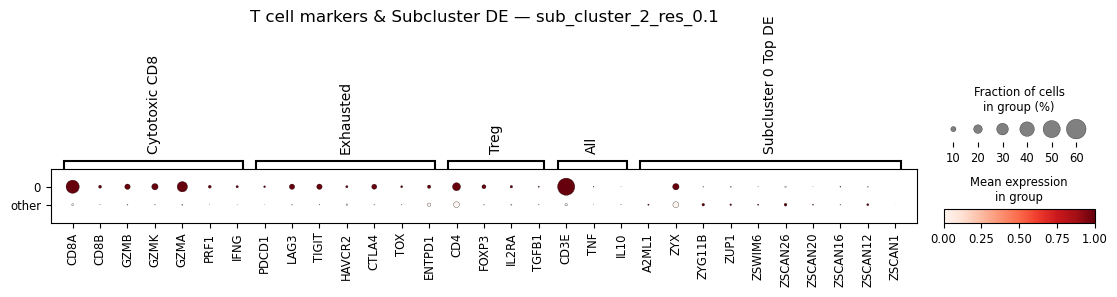


Sub-cluster sizes for sub_cluster_2_res_0.1:
sub_cluster_2_res_0.1
other    97604
0        14947
Name: count, dtype: int64
Starting Sub Resolutions 0.05


/global/home/users/fosterangus/.conda/envs/scvi/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:380: RuntimeWarning: invalid value encountered in divide
  scores[group_index, :] = (


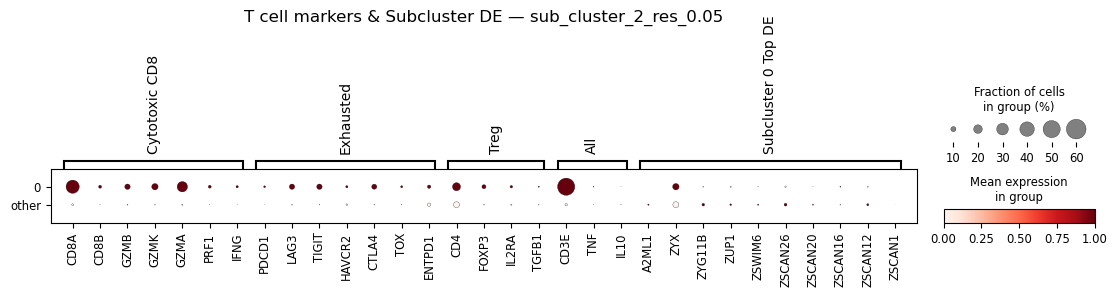


Sub-cluster sizes for sub_cluster_2_res_0.05:
sub_cluster_2_res_0.05
other    97604
0        14947
Name: count, dtype: int64


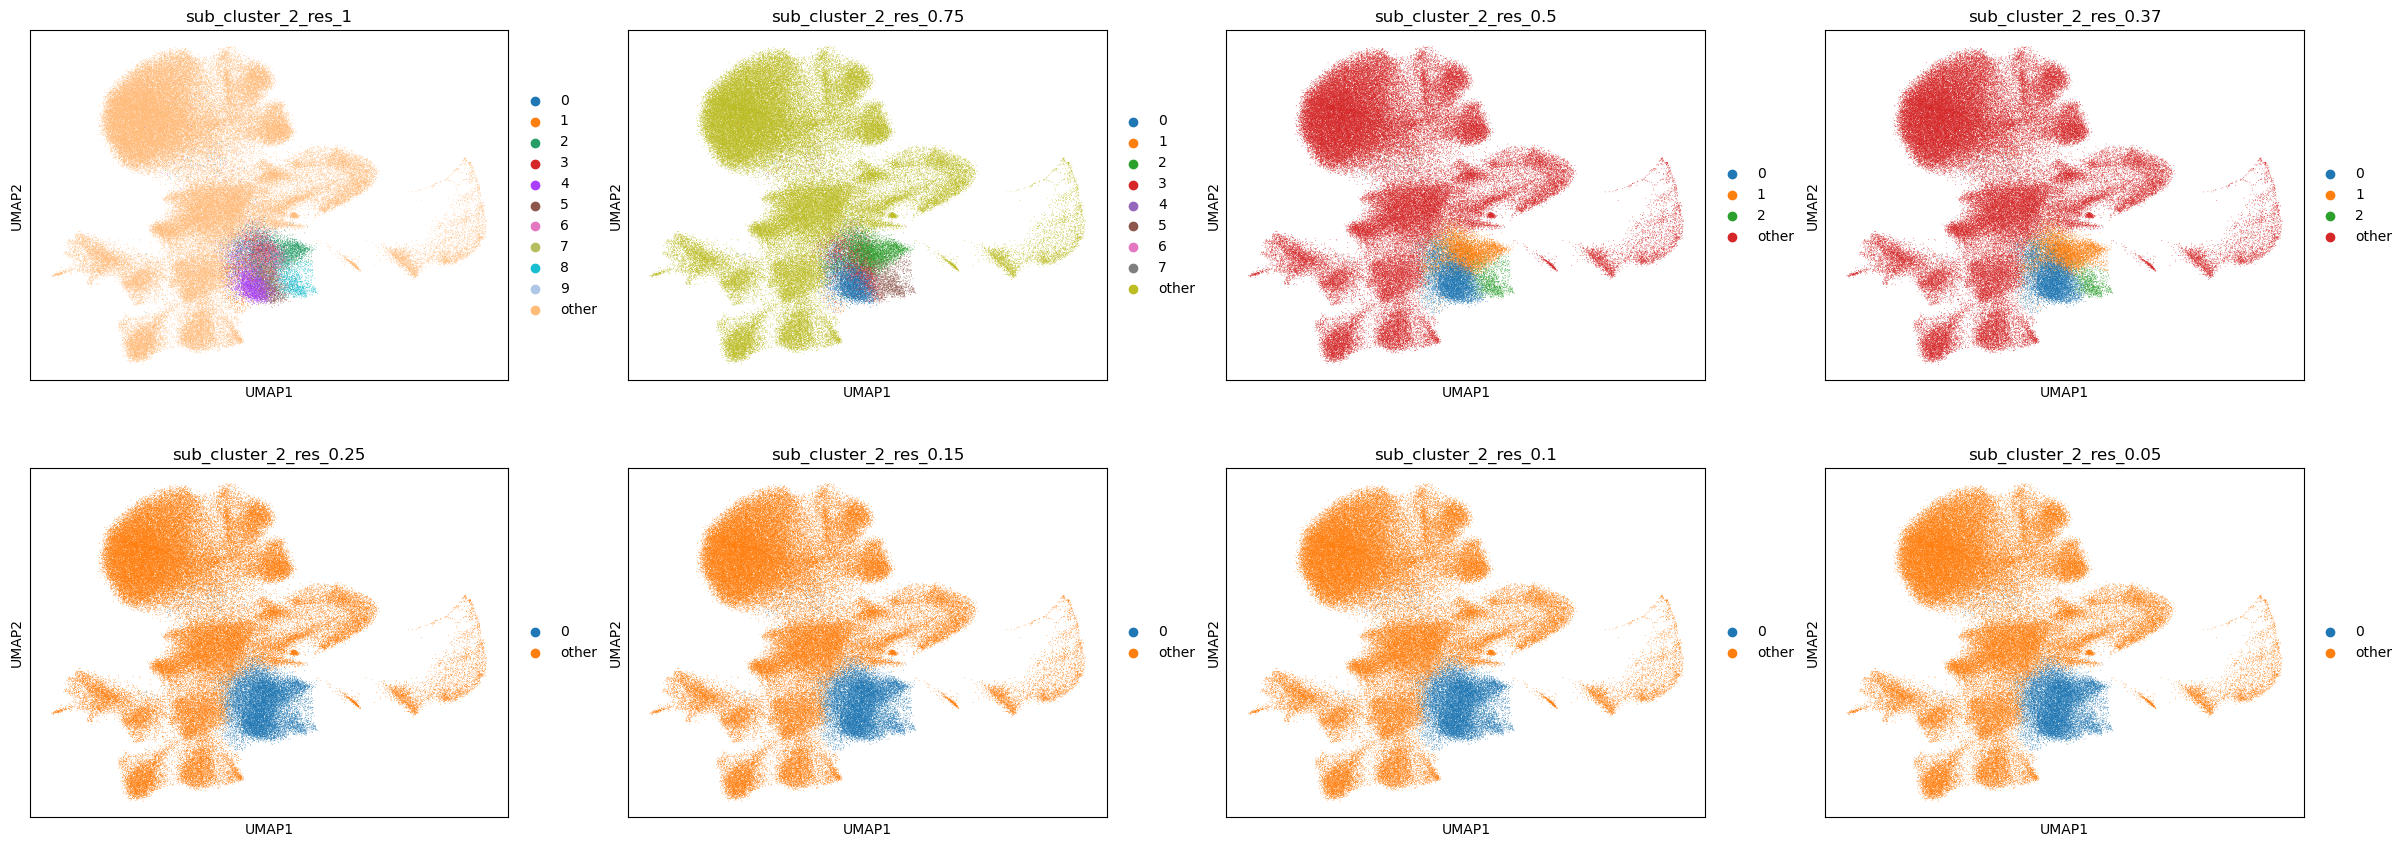

In [17]:
print('starting cd8')
for sub_res in sub_resolutions:
    subcluster(adata, cd8, sub_res, clusters_res_label=res_label(res), de_genes_dict=de_genes_dict)
sc.pl.umap(adata, color=[sub_res_label(sub_res, cd8) for sub_res in sub_resolutions])

In [18]:
# ============================================================
# Time to assign  -  fine T-cell annotations from collaborator's notes.
# "We only want T cells": a cell is kept as a T cell ONLY if it lands in a
# subcluster she explicitly annotated. Everything else -- the contaminated CD4
# cluster(s) and any un-annotated CD8/CD4 subcluster -- is contamination/noise
# and set to 'other' at ALL tiers (Tier1 is removed for noise, not just Tier3).
#
# IMPORTANT: the sub-resolutions below MUST match those used in the subcluster
# loop above (sub_resolutions). We build the column via sub_res_label() and
# assert it exists so a resolution mismatch fails loudly instead of mislabeling.
# ============================================================

# --- CD8 subcluster annotations ---
cd8_sub_res = 0.75
cd8_labels = {'0': 'Effector CD8 T cell', '3': 'Gamma delta T cell', '4': 'ISG CD8 T cell', '5': 'Proliferating CD8 T cell'}

# --- CD4 subcluster annotations ---  (None => CD4 is contamination)
cd4_sub_res = None
cd4_labels = {}

cd8_sub_col = sub_res_label(cd8_sub_res, cd8) if cd8_sub_res is not None else None
cd4_sub_col = sub_res_label(cd4_sub_res, cd4) if cd4_sub_res is not None else None
if cd8_sub_col is not None:
    assert cd8_sub_col in adata.obs, f"{cd8_sub_col} missing -- run the CD8 subcluster loop at res {cd8_sub_res}"
if cd4_sub_col is not None:
    assert cd4_sub_col in adata.obs, f"{cd4_sub_col} missing -- run the CD4 subcluster loop at res {cd4_sub_res}"

# Tier3: fine functional label, only for annotated subclusters
adata.obs['Tier3'] = 'other'
if cd8_sub_col is not None:
    for clust, label in cd8_labels.items():
        adata.obs.loc[adata.obs[cd8_sub_col] == clust, 'Tier3'] = label
if cd4_sub_col is not None:
    for clust, label in cd4_labels.items():
        adata.obs.loc[adata.obs[cd4_sub_col] == clust, 'Tier3'] = label
adata.obs['Tier3'] = adata.obs['Tier3'].astype('category')

# A cell is a real T cell iff it received a Tier3 label.
is_tcell = adata.obs['Tier3'] != 'other'

# Tier2: CD8- vs CD4-origin, only for confirmed T cells
adata.obs['Tier2'] = 'other'
if cd8_sub_col is not None:
    adata.obs.loc[is_tcell & adata.obs[cd8_sub_col].isin(list(cd8_labels)), 'Tier2'] = 'CD8 T Cell'
if cd4_sub_col is not None:
    adata.obs.loc[is_tcell & adata.obs[cd4_sub_col].isin(list(cd4_labels)), 'Tier2'] = 'CD4 T Cell'
adata.obs['Tier2'] = adata.obs['Tier2'].astype('category')

# Tier1: 'T Cell' ONLY where a fine label was assigned (noise/contamination dropped)
adata.obs['Tier1'] = np.where(is_tcell, 'T Cell', 'other')
adata.obs['Tier1'] = adata.obs['Tier1'].astype('category')

# Keep the exploratory boolean flags consistent with the cleaned annotation
adata.obs['t_cell'] = is_tcell
adata.obs['cd8'] = adata.obs['Tier2'] == 'CD8 T Cell'
adata.obs['cd4'] = adata.obs['Tier2'] == 'CD4 T Cell'

print("Tier1:\n", adata.obs['Tier1'].value_counts())
print("\nTier2:\n", adata.obs['Tier2'].value_counts())
print("\nTier3:\n", adata.obs['Tier3'].value_counts())


Tier1:
 Tier1
other     103187
T Cell      9364
Name: count, dtype: int64

Tier2:
 Tier2
other         103187
CD8 T Cell      9364
Name: count, dtype: int64

Tier3:
 Tier3
other                       103187
Effector CD8 T cell           4715
Gamma delta T cell            2417
Proliferating CD8 T cell      1993
ISG CD8 T cell                 239
Name: count, dtype: int64


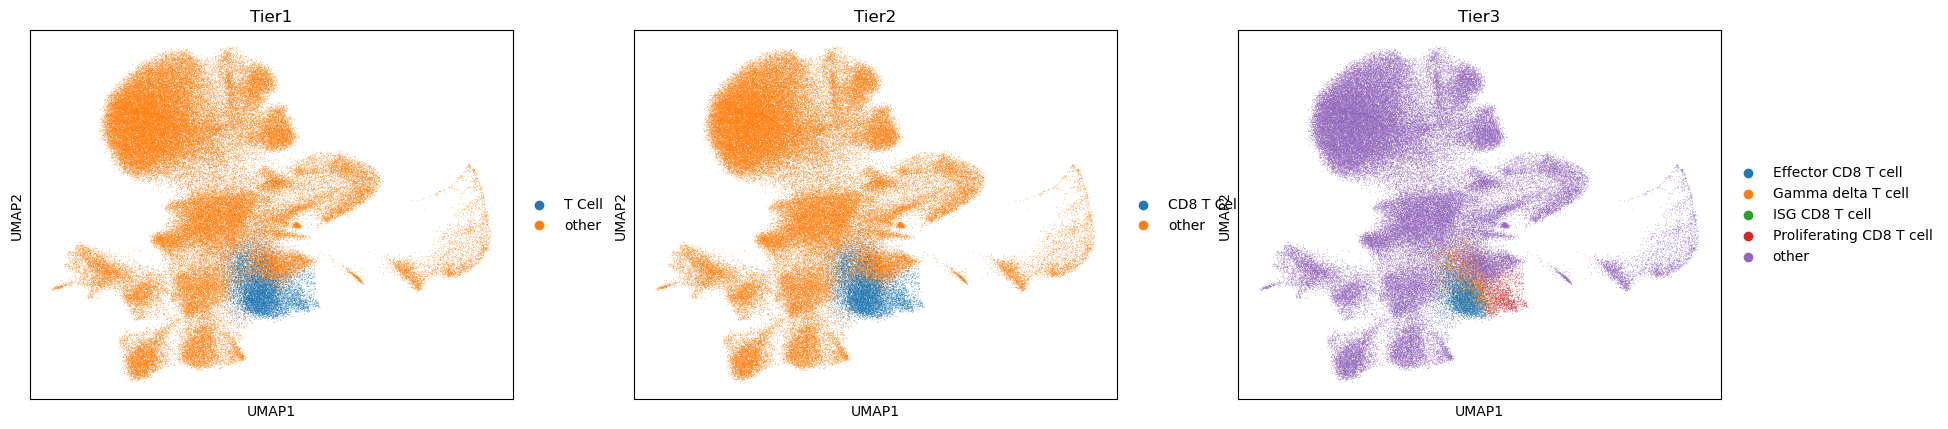

In [19]:
sc.pl.umap(adata, color=['Tier1', 'Tier2', 'Tier3'])

In [23]:
adata.write_h5ad(f'{DATA_DIR}/adata.h5ad')